היי!
אם מישהו נכנס למחברת הזו, אז יש משהו שאתה צריך לדעת\

במודל של הHMM


יש בעיה לגבי ההסתברויות של ההישארות או ההחלפה של ההחלטה
הספרייה שעוזרת לאמן את המודל החליפה לי את הלייבל, ובטעות כל ההדפסות הן עם הישארות למרות שבתכלס זה מחשב החלפה
ולכן אם יש שני תאים עם הדפסות שהן נראות זהות אבל עם מספרים שונים אחד אחרי השני, התייחסו לשני, כי שם מחושבות ההסתברויות עם הפרשנות הנכונה -
שזה פשוט אחת פחות ממה שיש בתא הראשון בד"כ

תודה!

In [ ]:
!pip install pyreadr

In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import pyreadr
import urllib.request

# 1. הורדת הקובץ הגולמי מ-GitHub
url = "https://raw.githubusercontent.com/fdvorak/stratEst/master/data/WXZ2014.rda"
urllib.request.urlretrieve(url, "WXZ2014.rda")

# המרת הקובץ ל-DataFrame של Pandas
result = pyreadr.read_r("WXZ2014.rda")
df = result["WXZ2014"]

print("נתונים גולמיים נטענו בהצלחה:")
print(df.head())

נתונים גולמיים נטענו בהצלחה:
    id  game  period choice other.choice result
0  1.0   1.0       1      s            s    tie
1  1.0   1.0       2      s            r   lose
2  1.0   1.0       3      s            p    win
3  1.0   1.0       4      s            p    win
4  1.0   1.0       5      s            p    win


In [ ]:
# 1. משתנה התגובה הליניארי: האם השחקן שמר על אותו מהלך (Stay = 1, Shift = 0)
df["prev_choice"] = df.groupby("id")["choice"].shift(1)
df["stay"] = (df["choice"] == df["prev_choice"]).astype(int)

# 2. לאגים התנהגותיים (Memory Components)
df["stay_lag1"] = df.groupby("id")["stay"].shift(1)
df["stay_lag2"] = df.groupby("id")["stay"].shift(2)

# 3. תוצאת הסיבוב הקודם (Feedback Loop)
df["result_prev"] = df.groupby("id")["result"].shift(1)

# יצירת המשתנים המסווגים (Dummies) לכל תוצאה בסיבוב הקודם: Win, Lose, Draw (Tie)
# הערה: יש לוודא מה הערכים המדויקים בעמודת result (למשל: 'win', 'loss'/'lose', 'draw'/'tie')
df["result_prev_win"] = (df["result_prev"] == "win").astype(int)
df["result_prev_lose"] = (
    df["result_prev"].isin(["lose", "loss"]).astype(int)
)  # התאמה גמישה לרישום
df["result_prev_draw"] = (
    df["result_prev"].isin(["draw", "tie"]).astype(int)
)  # הוספת משתנה ה-Tie!

# ניקוי ערכי NaN שנוצרו עקב ה-shift
df_clean = df.dropna().copy()

print("\nנתונים מעובדים לדוגמה:")
print(
    df_clean[
        [
            "id",
            "period",
            "choice",
            "stay",
            "stay_lag1",
            "result_prev",
            "result_prev_draw",
        ]
    ].head(10)
)


נתונים מעובדים לדוגמה:
     id  period choice  stay  stay_lag1 result_prev  result_prev_draw
2   1.0       3      s     1        1.0        lose                 0
3   1.0       4      s     1        1.0         win                 0
4   1.0       5      s     1        1.0         win                 0
5   1.0       6      r     0        1.0         win                 0
6   1.0       7      s     0        0.0         tie                 1
7   1.0       8      r     0        0.0         tie                 1
8   1.0       9      s     0        0.0         win                 0
9   1.0      10      r     0        0.0        lose                 0
10  1.0      11      p     0        0.0         tie                 1
11  1.0      12      p     1        0.0         win                 0


In [ ]:
# נרמול משתנה הזמן
df_clean["period_scaled"] = (
    df_clean["period"] - df_clean["period"].mean()
) / df_clean["period"].std()

# הגדרת אינדקסים לשחקנים (מ-0 עד N-1)
player_idxs = pd.Categorical(df_clean["id"]).codes
num_players = len(np.unique(player_idxs))

# חילוץ וקטורים של הנתונים עבור PyMC
y_data = df_clean["stay"].values
period_data = df_clean["period_scaled"].values
lag1_data = df_clean["stay_lag1"].values
win_data = df_clean["result_prev_win"].values
lose_data = df_clean["result_prev_lose"].values
draw_data = df_clean[
    "result_prev_draw"
].values  # משתנה ה-Tie-Shift המוזן למודל

In [ ]:
pip install numpyro jax jaxlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 12.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

np.random.seed(42)

# =========================================================
# 0. הכנת נתונים
# =========================================================
all_player_ids = df_clean["id"].unique()
num_players = len(all_player_ids)
player_id_to_idx = {pid: i for i, pid in enumerate(all_player_ids)}

player_idxs = df_clean["id"].map(player_id_to_idx).values
period_scaled = ((df_clean["period"] - df_clean["period"].mean()) / df_clean["period"].std()).values
y_data = df_clean["stay"].values
lag1_data = df_clean["stay_lag1"].values
win_data = df_clean["result_prev_win"].values
lose_data = df_clean["result_prev_lose"].values
draw_data = df_clean["result_prev_draw"].values

# =========================================================
# 1. מודל בייסיאני היררכי - גרסה מתוקנת (ללא alpha כללי!)
#
#    התיקון הקריטי: הסרנו את alpha לגמרי. win/lose/draw הן
#    dummies בלעדיות הדדית (בדיוק אחת שווה 1 בכל שורה), אז
#    intercept + שלוש ה-dummies יוצר collinearity מושלמת
#    (1 = win+lose+draw בדיוק). ה"פיצול" בין alpha לבין
#    שלושת ה-beta-ים היה תלוי אך ורק ב-priors, לא בנתונים.
#
#    עכשיו beta_win[i], beta_lose[i], beta_draw[i] הם עצמם
#    ה-logit(P(Stay)) המלא של שחקן i בכל תרחיש - בדיוק כמו
#    שכל מצב ב-HMM מגדיר logit מלא (W_k) בלי intercept נפרד.
#    זה גם הופך את ההשוואה מול ה-HMM ל-apples-to-apples אמיתי.
# =========================================================
print("--- Training Hierarchical Bayesian Model (Identifiability-Fixed) ---")
with pm.Model() as random_slopes_model_fixed:

    player_data_pm = pm.Data("player_idxs", player_idxs)
    period_data_pm = pm.Data("period_data", period_scaled)
    lag1_data_pm = pm.Data("lag1_data", lag1_data)
    win_data_pm = pm.Data("win_data", win_data)
    lose_data_pm = pm.Data("lose_data", lose_data)
    draw_data_pm = pm.Data("draw_data", draw_data)
    y_data_pm = pm.Data("y_obs_data", y_data)

    # --- Random Slope: beta_win (= logit(P(Stay|win)) הישיר של כל שחקן) ---
    mu_beta_win = pm.Normal("mu_beta_win", mu=0, sigma=1.5)
    sigma_beta_win = pm.HalfNormal("sigma_beta_win", sigma=1.0)
    beta_win_offset = pm.Normal("beta_win_offset", mu=0, sigma=1, shape=num_players)
    beta_win = pm.Deterministic("beta_win", mu_beta_win + beta_win_offset * sigma_beta_win)

    # --- Random Slope: beta_lose (= logit(P(Stay|lose)) הישיר) ---
    mu_beta_lose = pm.Normal("mu_beta_lose", mu=0, sigma=1.5)
    sigma_beta_lose = pm.HalfNormal("sigma_beta_lose", sigma=1.0)
    beta_lose_offset = pm.Normal("beta_lose_offset", mu=0, sigma=1, shape=num_players)
    beta_lose = pm.Deterministic("beta_lose", mu_beta_lose + beta_lose_offset * sigma_beta_lose)

    # --- Random Slope: beta_draw (= logit(P(Stay|draw)) הישיר) ---
    mu_beta_draw = pm.Normal("mu_beta_draw", mu=0, sigma=1.5)
    sigma_beta_draw = pm.HalfNormal("sigma_beta_draw", sigma=1.0)
    beta_draw_offset = pm.Normal("beta_draw_offset", mu=0, sigma=1, shape=num_players)
    beta_draw = pm.Deterministic("beta_draw", mu_beta_draw + beta_draw_offset * sigma_beta_draw)

    # --- אפקטים קבועים נוספים (לא קולינאריים עם win/lose/draw) ---
    beta_period = pm.Normal("beta_period", mu=0, sigma=1)
    beta_lag1 = pm.Normal("beta_lag1", mu=0, sigma=1)

    # שים לב: אין יותר alpha! win+lose+draw מכסות את כל השורות
    # (בדיוק אחת מהן =1 תמיד), אז אין צורך ולא ניתן להוסיף עוד
    # intercept כללי בלי לשבור identifiability מחדש.
    mu_logit = (
        beta_win[player_data_pm] * win_data_pm
        + beta_lose[player_data_pm] * lose_data_pm
        + beta_draw[player_data_pm] * draw_data_pm
        + beta_period * period_data_pm
        + beta_lag1 * lag1_data_pm
    )

    y_obs = pm.Bernoulli("y_obs", logit_p=mu_logit, observed=y_data_pm)

    trace_rs_fixed = pm.sample(draws=1000, tune=1000, target_accept=0.95, nuts_sampler="numpyro")

# =========================================================
# 2. תוצאות ברמת האוכלוסייה
# =========================================================
print("\n--- Population-Level Summary ---")
summary = az.summary(trace_rs_fixed, var_names=["mu_beta_win", "sigma_beta_win",
                                                 "mu_beta_lose", "sigma_beta_lose",
                                                 "mu_beta_draw", "sigma_beta_draw",
                                                 "beta_period", "beta_lag1"])
print(summary)

print("""
פרשנות מהירה (אחרי התיקון):
- mu_beta_lose : logit(P(Stay|Lose)) הממוצע באוכלוסייה - ישיר, לא ביחס
  ל-baseline נסתר. ניתן להשוואה ישירה ל-W_k[lose] של כל מצב ב-HMM.
- sigma_beta_lose : הטרוגניות אמיתית בין שחקנים (לא מעורבת יותר
  בבעיית identifiability עם intercept).
""")

# =========================================================
# 3. שמירה לדיסק
# =========================================================
trace_rs_fixed.to_netcdf("/content/trace_random_slopes_fixed.nc")
print("Trace saved to /content/trace_random_slopes_fixed.nc")

--- Training Hierarchical Bayesian Model (Identifiability-Fixed) ---


/usr/local/lib/python3.12/dist-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [01:02<00:00, 31.90it/s, 31 steps of size 1.33e-01. acc. prob=0.95]
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



--- Population-Level Summary ---
                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_beta_win     -0.675  0.086  -0.852   -0.529      0.005    0.002     333.0   
sigma_beta_win   0.710  0.067   0.587    0.834      0.003    0.002     526.0   
mu_beta_lose     0.183  0.171  -0.125    0.493      0.020    0.008      75.0   
sigma_beta_lose  1.456  0.139   1.201    1.716      0.009    0.005     230.0   
mu_beta_draw    -0.323  0.097  -0.504   -0.136      0.006    0.003     223.0   
sigma_beta_draw  0.766  0.073   0.639    0.909      0.004    0.002     421.0   
beta_period      0.066  0.015   0.039    0.094      0.000    0.000    3448.0   
beta_lag1        0.081  0.032   0.022    0.142      0.001    0.001    3544.0   

                 ess_tail  r_hat  
mu_beta_win         734.0   1.01  
sigma_beta_win      822.0   1.00  
mu_beta_lose        222.0   1.01  
sigma_beta_lose     509.0   1.00  
mu_beta_draw        304.0   1.00  
sigma_beta_draw     924.0   1.01  


הגרף נשמר בהצלחה כ-bayesian_tie_shift_architecture.png


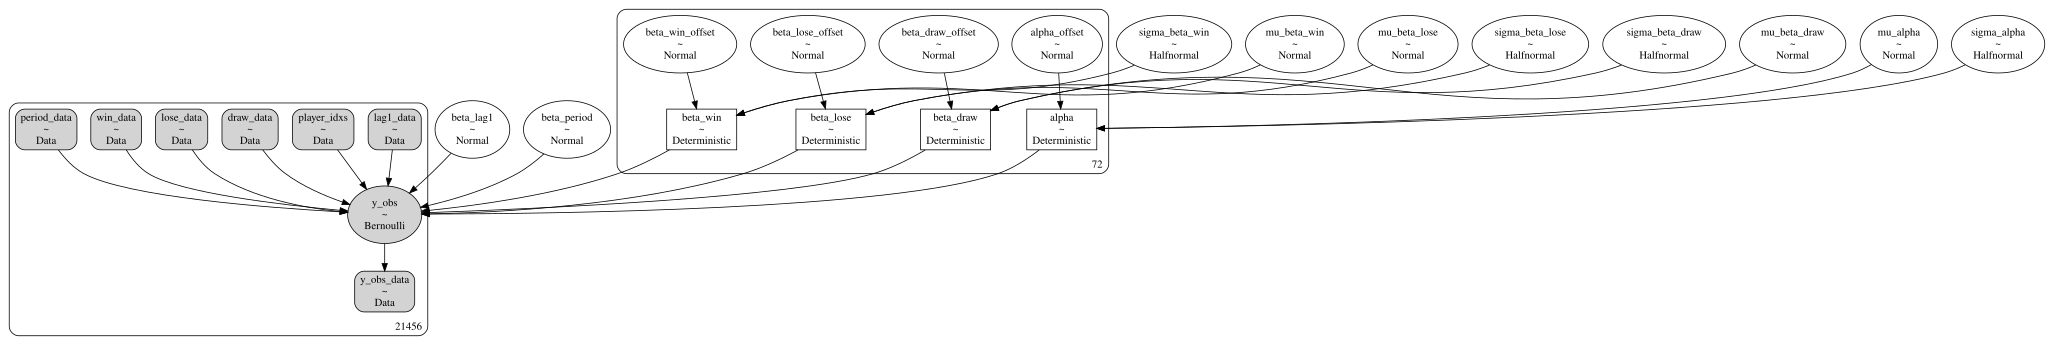

In [ ]:
# 1. יצירת הגרף הוויזואלי של המודל
graph = pm.model_to_graphviz(random_slopes_model)

# 2. שמירה כקובץ תמונה לשימוש ב-Slide / דוח
try:
  graph.render(
      filename="bayesian_tie_shift_architecture", format="png", cleanup=True
  )
  print("הגרף נשמר בהצלחה כ-bayesian_tie_shift_architecture.png")
except Exception as e:
  print("Graphviz לא מותקן ברמת מערכת ההפעלה, אך הגרף עדיין יוצג ב-Notebook.")

# 3. הצגת הגרף
graph

In [ ]:
pip install hmmlearn

In [ ]:
import numpy as np
import pandas as pd
from hmmlearn import hmm

# 1. הכנת הנתונים
# ב-hmmlearn, סדרות הזמן צריכות להתקבל כמטריצה דו-ממדית (N_samples, 1)
# במידה ורוצים לאמן על שחקן יחיד או על כל השחקנים ברצף:
X = df_clean["stay"].values.reshape(-1, 1)

# אם יש כמה שחקנים, מעבירים גם את האורך של הסדרה של כל שחקן
lengths = df_clean.groupby("id").size().values

# 2. הגדרת מודל HMM עם התפלגות ברנולי/דיסקרטית (CategoricalHMM)
# K=2 מצבים נסתרים
model_2s = hmm.CategoricalHMM(
    n_components=2, n_iter=100, random_state=42, init_params="ste"
)

# 3. אימון המודל (אלגוריתם EM / Baum-Welch)
model_2s.fit(X, lengths=lengths)

print("--- מודל HMM אומן בהצלחה! ---")

# 4. חילוץ הפרמטרים שנלמדו
print("\nמטריצת מעברי המצבים (Transition Matrix):")
print(model_2s.transmat_)

print("\nהסתברויות הפליטה (Emission Probabilities - P(Stay | State)):")
# עמודה 0 = Shift, עמודה 1 = Stay
print(model_2s.emissionprob_)

--- מודל HMM אומן בהצלחה! ---

מטריצת מעברי המצבים (Transition Matrix):
[[0.85776591 0.14223409]
 [0.998129   0.001871  ]]

הסתברויות הפליטה (Emission Probabilities - P(Stay | State)):
[[0.55589712 0.44410288]
 [0.59017102 0.40982898]]


In [ ]:
# שחזור המצבים הנסתרים עבור כל סיבוב
hidden_states2 = model_2s.predict(X, lengths=lengths)
df_clean["hidden_state_2"] = hidden_states2

GLM HMM

In [ ]:
import pandas as pd
import numpy as np

# 1. יצירת וקטור התצפיות (Y_t)
# הפעולה בפועל בסיבוב הנוכחי (למשל: Stay=1, Shift=0)
Y = df_clean['stay'].values.reshape(-1, 1)

# 2. יצירת מטריצת המשתנים המסבירים (X_t)
# ניצור משתני דמה (One-Hot Encoding) עבור תוצאת הסיבוב הקודם
X_df = pd.get_dummies(df_clean['result_prev'])

# מומלץ לוודא שהעמודות מסודרות בצורה נוחה.
# X תהיה מטריצה בגודל (T, 3)
X = X_df[['win', 'lose', 'tie']].astype(float).values

print(f"Observations shape (Y): {Y.shape}")
print(f"Covariates shape (X): {X.shape}")

Observations shape (Y): (21456, 1)
Covariates shape (X): (21456, 3)


In [ ]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-b87k9hjg
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-b87k9hjg
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done


In [ ]:
import sys
import types
import scipy.special

# 1. Create fake autograd.scipy.misc module in sys.modules
misc_module = types.ModuleType("autograd.scipy.misc")
misc_module.logsumexp = scipy.special.logsumexp

# 2. Inject it into sys.modules
sys.modules["autograd.scipy.misc"] = misc_module

# 3. Import ssm now
import ssm
print("SSM imported successfully!")

SSM imported successfully!


In [ ]:
import sys
import types
import autograd.scipy.special as ag_special

# 1. Create fake autograd.scipy.misc using AUTOGRAD'S logsumexp wrapper
misc_module = types.ModuleType("autograd.scipy.misc")
misc_module.logsumexp = ag_special.logsumexp

# 2. Inject into sys.modules
sys.modules["autograd.scipy.misc"] = misc_module

# 3. Patch scipy.special inside ssm.transitions module directly to use autograd's logsumexp
import ssm.transitions
ssm.transitions.logsumexp = ag_special.logsumexp

print("Patched autograd logsumexp successfully!")

Patched autograd logsumexp successfully!


# Input driven transitions GLM HMM

Observations shape (Y): (21456, 1)
Covariates shape (X): (21456, 3)

Starting EM optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

Optimization finished.


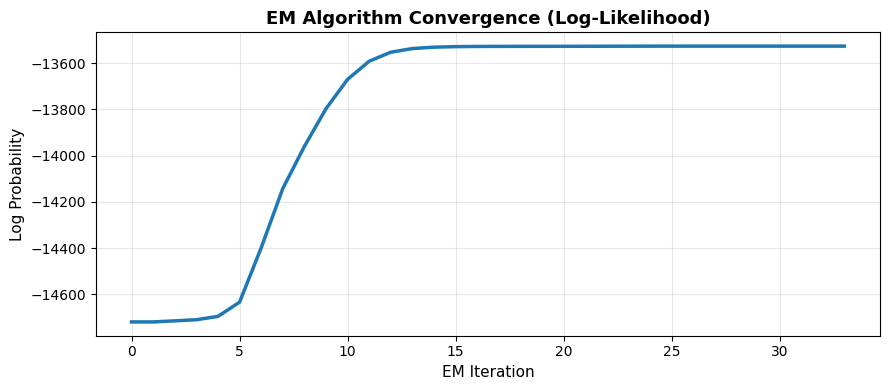


--- Transition Matrices Weights (Beta) ---
Shape (K, K, M): (2, 3)

--- Emission Probabilities P(Stay=1 | State) ---
State 0: 0.301
State 1: 0.690


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ssm

# ---------------------------------------------------------
# 1. Data Preparation (Y_t and X_t)
# ---------------------------------------------------------
# Y: The observations (Stay=1, Shift=0). Must be integers of shape (T, 1)
Y = df_clean["stay"].values.astype(int).reshape(-1, 1)

# X: The covariates (Win, Lose, Tie). We use one-hot encoding.
X_df = pd.get_dummies(df_clean["result_prev"])
# Enforcing the specific order of covariates and shape (T, M)
X = X_df[["win", "lose", "tie"]].astype(float).values

print(f"Observations shape (Y): {Y.shape}")
print(f"Covariates shape (X): {X.shape}")

# ---------------------------------------------------------
# 2. Model Initialization
# ---------------------------------------------------------
K = 2  # Number of hidden states (Dynamic vs Freezing)
D = 1  # Dimension of observation (1D: Stay/Shift)
M = X.shape[1]  # Number of covariates (3: win, lose, tie)

# Creating the GLM-HMM object
glm_hmm = ssm.HMM(K, D, M, observations="bernoulli", transitions="inputdriven")

# ---------------------------------------------------------
# 3. Model Training (EM Algorithm)
# ---------------------------------------------------------
print("\nStarting EM optimization...")

# Passing datas and inputs as lists of arrays (standard ssm requirement for sequences)
fit_ll = glm_hmm.fit(
    [Y], inputs=[X], method="em", num_em_iters=200, tolerance=1e-4
)

print("Optimization finished.")

# ---------------------------------------------------------
# 4. Plotting Convergence
# ---------------------------------------------------------
plt.figure(figsize=(9, 4))
plt.plot(fit_ll, color="#1f77b4", linewidth=2.5)
plt.title(
    "EM Algorithm Convergence (Log-Likelihood)", fontsize=13, fontweight="bold"
)
plt.xlabel("EM Iteration", fontsize=11)
plt.ylabel("Log Probability", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Extracting the Learned Parameters
# ---------------------------------------------------------
transition_weights = glm_hmm.transitions.Ws
print("\n--- Transition Matrices Weights (Beta) ---")
print("Shape (K, K, M):", transition_weights.shape)

# FIXED: Use logit_ps and convert to probabilities via sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

emission_logits = glm_hmm.observations.logit_ps
emission_probs = sigmoid(emission_logits)

print("\n--- Emission Probabilities P(Stay=1 | State) ---")
for k in range(K):
    print(f"State {k}: {emission_probs[k][0]:.3f}")

In [ ]:
# ---------------------------------------------------------
# 6. Goodness-of-Fit (GOF) Metrics
# ---------------------------------------------------------
# ה-Log-Likelihood הסופי הוא הערך האחרון במערך ההתכנסות של אלגוריתם ה-EM
log_likelihood = fit_ll[-1]

# חישוב מספר הפרמטרים החופשיים (p) במודל Transitions-Only:
# 1. פליטות (Bernoulli): פרמטר 1 לכל מצב -> K = 2 פרמטרים.
# 2. מעברים (Input-Driven): K * (K - 1) * M משקולות -> 2 * 1 * 3 = 6 פרמטרים.
# סך הכל מודל זה משתמש ב-8 פרמטרים חופשיים (בהנחה שהמצב ההתחלתי קבוע או שולי).
n_params = K + (K * (K - 1) * M)

N_total = len(Y)  # סך כל התצפיות

# חישוב המדדים
aic = 2 * n_params - 2 * log_likelihood
bic = np.log(N_total) * n_params - 2 * log_likelihood

print("\n==================================================")
print("       MODEL GOODNESS-OF-FIT (Transitions-Only)     ")
print("==================================================")
print(f"Number of Parameters (p): {n_params}")
print(f"Log-Likelihood          : {log_likelihood:.4f}")
print(f"AIC Score               : {aic:.4f}")
print(f"BIC Score               : {bic:.4f}")


       MODEL GOODNESS-OF-FIT (Transitions-Only)     
Number of Parameters (p): 8
Log-Likelihood          : -13526.8614
AIC Score               : 27069.7228
BIC Score               : 27133.5129


In [ ]:
import numpy as np
import pandas as pd


# פונקציית סיגמואיד להמרת הלוג'יטים להסתברויות
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# 1. Emission Probabilities P(Stay=1 | State)
# ssm stores Bernoulli logits in .logit_ps
logits = glm_hmm.observations.logit_ps
emission_probs = sigmoid(logits)

print("==================================================")
print("             EMISSION PROBABILITIES               ")
print("==================================================")
for k in range(K):
    p_stay = emission_probs[k][0]
    print(
        f"State {k}: P(Stay = 1) = {p_stay:.4f}  |  P(Shift = 0) = {1 - p_stay:.4f}"
    )

# 2. Transition Weights (Beta Matrix)
weights = glm_hmm.transitions.Ws
covariate_names = ["Win", "Lose", "Tie"]

print("\n==================================================")
print("       TRANSITION WEIGHTS (GLM BETA COEFFICIENTS) ")
print("==================================================")

if weights.ndim == 3:
    for i in range(K):
        for j in range(K):
            print(f"\n--- From State {i} -> To State {j} ---")
            for m, name in enumerate(covariate_names):
                print(f"  Covariate [{name}]: Beta = {weights[i, j, m]:.4f}")
else:
    for i in range(weights.shape[0]):
        print(f"\n--- Transition Logit Weights for State {i} ---")
        for m, name in enumerate(covariate_names):
            print(f"  Covariate [{name}]: Beta = {weights[i, m]:.4f}")

             EMISSION PROBABILITIES               
State 0: P(Stay = 1) = 0.3012  |  P(Shift = 0) = 0.6988
State 1: P(Stay = 1) = 0.6898  |  P(Shift = 0) = 0.3102

       TRANSITION WEIGHTS (GLM BETA COEFFICIENTS) 

--- Transition Logit Weights for State 0 ---
  Covariate [Win]: Beta = 0.4277
  Covariate [Lose]: Beta = -1.3719
  Covariate [Tie]: Beta = 0.0117

--- Transition Logit Weights for State 1 ---
  Covariate [Win]: Beta = -0.0188
  Covariate [Lose]: Beta = -0.3588
  Covariate [Tie]: Beta = 1.1067


# Emissions only GLM HMM

In [ ]:
# =========================================================
#  EMISSIONS-ONLY GLM-HMM
# (Static Transitions, Input-Driven Emissions)
# =========================================================
print("==================================================")
print(" 1. Training Emissions-Only GLM-HMM")
print("==================================================")

# observations="input_driven_obs" -> פליטות מושפעות מ-X
# transitions="standard" -> מעברים סטטיים רגילים (מרקוביים)
glm_hmm_emissions = ssm.HMM(K, D, M,
                            observations="input_driven_obs",
                            observation_kwargs=dict(C=2),
                            transitions="standard")

fit_ll_em = glm_hmm_emissions.fit([Y], inputs=[X], method="em", num_em_iters=200, tolerance=1e-4)
ll_em = fit_ll_em[-1]

# חישוב מספר הפרמטרים (p=8)
# פליטות (GLM): K * M = 6 (יש 2 מצבים * 3 משתני פידבק)
p_em = K * (K - 1) + K * M

aic_em = 2 * p_em - 2 * ll_em
bic_em = np.log(len(Y)) * p_em - 2 * ll_em

print("\n--- GOF: Emissions-Only GLM-HMM ---")
print(f"Number of Parameters (p): {p_em}")
print(f"Log-Likelihood          : {ll_em:.4f}")
print(f"AIC Score               : {aic_em:.4f}")
print(f"BIC Score               : {bic_em:.4f}\n")




 1. Training Emissions-Only GLM-HMM


  0%|          | 0/100 [00:00<?, ?it/s]


--- GOF: Emissions-Only GLM-HMM ---
Number of Parameters (p): 8
Log-Likelihood          : -13097.3548
AIC Score               : 26210.7096
BIC Score               : 26274.4997



# Full GLM HMM

In [ ]:
# =========================================================
#  FULL GLM-HMM
# (Input-Driven Transitions AND Input-Driven Emissions)
# =========================================================
print("==================================================")
print(" 2. Training Full GLM-HMM (Combined)")
print("==================================================")

# שניהם מונעים מ-X (גם transitions וגם observations)
glm_hmm_full = ssm.HMM(K, D, M,
                       observations="input_driven_obs",
                       observation_kwargs=dict(C=2),
                       transitions="inputdriven")

fit_ll_full = glm_hmm_full.fit([Y], inputs=[X], method="em", num_em_iters=200, tolerance=1e-4)
ll_full = fit_ll_full[-1]

# חישוב מספר הפרמטרים (p=14)
# מעברים (GLM + Baseline): K * (K - 1) * M + K * (K - 1) = 6 + 2 = 8
# פליטות (GLM): K * M = 6
p_full = K * (K - 1) * M + K * (K - 1) + K * M

aic_full = 2 * p_full - 2 * ll_full
bic_full = np.log(len(Y)) * p_full - 2 * ll_full

print("\n--- GOF: Full GLM-HMM (Combined) ---")
print(f"Number of Parameters (p): {p_full}")
print(f"Log-Likelihood          : {ll_full:.4f}")
print(f"AIC Score               : {aic_full:.4f}")
print(f"BIC Score               : {bic_full:.4f}")

 2. Training Full GLM-HMM (Combined)


  0%|          | 0/100 [00:00<?, ?it/s]


--- GOF: Full GLM-HMM (Combined) ---
Number of Parameters (p): 14
Log-Likelihood          : -13094.8533
AIC Score               : 26217.7067
BIC Score               : 26329.3393


Sequences: 72 players | Total observations: 21456

--- Fitting K = 1 ---
  LogLik = -14535.20 | params = 3 | AIC = 29076.4 | BIC = 29100.3

--- Fitting K = 2 ---
  LogLik = -13071.10 | params = 9 | AIC = 26160.2 | BIC = 26232.0

--- Fitting K = 3 ---
  LogLik = -12776.77 | params = 17 | AIC = 25587.5 | BIC = 25723.1

--- Fitting K = 4 ---
  LogLik = -12644.34 | params = 27 | AIC = 25342.7 | BIC = 25558.0

            MODEL SELECTION SUMMARY
 K  Params    LogLik      AIC      BIC    ΔAIC    ΔBIC
 1       3 -14535.20 29076.41 29100.33 3733.73 3542.36
 2       9 -13071.10 26160.21 26231.97  817.53  674.00
 3      17 -12776.77 25587.55 25723.10  244.87  165.13
 4      27 -12644.34 25342.67 25557.97    0.00    0.00

Best by AIC: K = 4
Best by BIC: K = 4

Evidence for hidden states (K=1 vs. best model):
  ΔAIC = 3733.7   ΔBIC = 3542.4
  (ΔBIC > 10 is conventionally 'very strong' evidence against K=1)


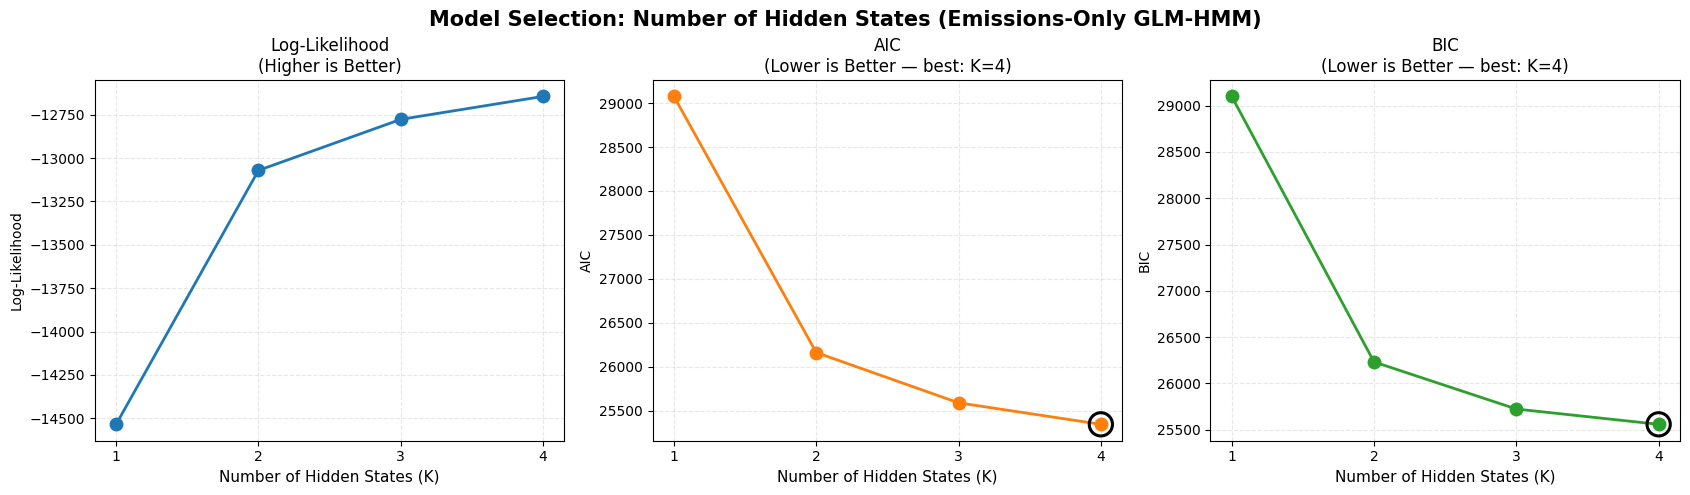


   P(Stay) BY STATE AND PREVIOUS OUTCOME  (K = 4)
                   Win      Lose       Tie
State 0           0.763     0.082     0.522
State 1           0.482     0.468     0.501
State 2           0.736     0.748     0.708
State 3           0.276     0.048     0.136

(Nash equilibrium in RPS implies P(Stay) = 1/3 ≈ 0.333)


In [ ]:
import numpy as np
import pandas as pd
import ssm
import matplotlib.pyplot as plt

# =========================================================
#  MODEL SELECTION: How many hidden states do we need?
#  Fits Emissions-Only GLM-HMM for K = 1, 2, 3, 4
#  K=1 is the crucial baseline: a plain GLM with no hidden states
# =========================================================

# ---------------------------------------------------------
# 1. הכנת הנתונים כרשימה של רצפים (אחד לכל שחקן)
# ---------------------------------------------------------
Y_list, X_list = [], []

for pid, group in df_clean.groupby("id"):
    group = group.sort_values("period")

    Y_g = group["stay"].values.astype(int).reshape(-1, 1)

    X_df_g = pd.get_dummies(group["result_prev"])
    for col in ["win", "lose", "tie"]:
        if col not in X_df_g:
            X_df_g[col] = 0
    X_g = X_df_g[["win", "lose", "tie"]].astype(float).values

    Y_list.append(Y_g)
    X_list.append(X_g)

N_total = sum(len(y) for y in Y_list)   # סך כל התצפיות
D = 1                                   # ממד התצפית
M = X_list[0].shape[1]                  # מספר המשתנים המסבירים (3)

print(f"Sequences: {len(Y_list)} players | Total observations: {N_total}")

# ---------------------------------------------------------
# 2. אימון מודלים עבור כל ערך של K
# ---------------------------------------------------------
K_values = [1, 2, 3, 4]
results = []
fitted_models = {}

for K_try in K_values:
    print(f"\n--- Fitting K = {K_try} ---")

    model_k = ssm.HMM(
        K_try, D, M,
        observations="input_driven_obs",
        observation_kwargs=dict(C=2),
        transitions="standard"
    )

    lls = model_k.fit(
        Y_list, inputs=X_list,
        method="em", num_em_iters=200, tolerance=1e-4, verbose=False
    )
    ll = lls[-1]

    # ספירת פרמטרים חופשיים:
    #   מעברים (standard):  K * (K - 1)
    #   התפלגות התחלתית:    K - 1
    #   פליטות (GLM):       K * M
    n_params = K_try * (K_try - 1) + (K_try - 1) + K_try * M

    aic = 2 * n_params - 2 * ll
    bic = np.log(N_total) * n_params - 2 * ll

    results.append({
        "K": K_try,
        "Params": n_params,
        "LogLik": ll,
        "AIC": aic,
        "BIC": bic
    })
    fitted_models[K_try] = model_k

    print(f"  LogLik = {ll:.2f} | params = {n_params} | AIC = {aic:.1f} | BIC = {bic:.1f}")

df_selection = pd.DataFrame(results)

# ---------------------------------------------------------
# 3. חישוב הפרשים יחסית למודל הטוב ביותר (Delta AIC / Delta BIC)
# ---------------------------------------------------------
df_selection["ΔAIC"] = df_selection["AIC"] - df_selection["AIC"].min()
df_selection["ΔBIC"] = df_selection["BIC"] - df_selection["BIC"].min()

best_aic_K = int(df_selection.loc[df_selection["AIC"].idxmin(), "K"])
best_bic_K = int(df_selection.loc[df_selection["BIC"].idxmin(), "K"])

print("\n" + "=" * 60)
print("            MODEL SELECTION SUMMARY")
print("=" * 60)
print(df_selection.round(2).to_string(index=False))
print(f"\nBest by AIC: K = {best_aic_K}")
print(f"Best by BIC: K = {best_bic_K}")

# ההשוואה הקריטית: האם מצבים נסתרים בכלל נחוצים?
delta_vs_k1_aic = df_selection.loc[df_selection["K"] == 1, "AIC"].values[0] - df_selection["AIC"].min()
delta_vs_k1_bic = df_selection.loc[df_selection["K"] == 1, "BIC"].values[0] - df_selection["BIC"].min()
print(f"\nEvidence for hidden states (K=1 vs. best model):")
print(f"  ΔAIC = {delta_vs_k1_aic:.1f}   ΔBIC = {delta_vs_k1_bic:.1f}")
print("  (ΔBIC > 10 is conventionally 'very strong' evidence against K=1)")

# ---------------------------------------------------------
# 4. גרף השוואה
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "Model Selection: Number of Hidden States (Emissions-Only GLM-HMM)",
    fontsize=15, fontweight="bold"
)

Ks = df_selection["K"].values

# --- Log-Likelihood ---
axes[0].plot(Ks, df_selection["LogLik"], "o-", color="#1f77b4", linewidth=2, markersize=9)
axes[0].set_title("Log-Likelihood\n(Higher is Better)", fontsize=12)
axes[0].set_xlabel("Number of Hidden States (K)", fontsize=11)
axes[0].set_ylabel("Log-Likelihood")
axes[0].set_xticks(Ks)
axes[0].grid(alpha=0.3, linestyle="--")

# --- AIC ---
axes[1].plot(Ks, df_selection["AIC"], "o-", color="#ff7f0e", linewidth=2, markersize=9)
axes[1].scatter([best_aic_K], [df_selection["AIC"].min()],
                s=280, facecolors="none", edgecolors="black", linewidths=2.2, zorder=5)
axes[1].set_title(f"AIC\n(Lower is Better — best: K={best_aic_K})", fontsize=12)
axes[1].set_xlabel("Number of Hidden States (K)", fontsize=11)
axes[1].set_ylabel("AIC")
axes[1].set_xticks(Ks)
axes[1].grid(alpha=0.3, linestyle="--")

# --- BIC ---
axes[2].plot(Ks, df_selection["BIC"], "o-", color="#2ca02c", linewidth=2, markersize=9)
axes[2].scatter([best_bic_K], [df_selection["BIC"].min()],
                s=280, facecolors="none", edgecolors="black", linewidths=2.2, zorder=5)
axes[2].set_title(f"BIC\n(Lower is Better — best: K={best_bic_K})", fontsize=12)
axes[2].set_xlabel("Number of Hidden States (K)", fontsize=11)
axes[2].set_ylabel("BIC")
axes[2].set_xticks(Ks)
axes[2].grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.subplots_adjust(top=0.84)
plt.show()

# ---------------------------------------------------------
# 5. מה כל מצב "עושה" במודל הנבחר — פרשנות
# ---------------------------------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

best_model = fitted_models[best_bic_K]
W = np.vstack(best_model.observations.params).reshape(best_bic_K, M)

print("\n" + "=" * 60)
print(f"   P(Stay) BY STATE AND PREVIOUS OUTCOME  (K = {best_bic_K})")
print("=" * 60)
print(f"{'':<12}{'Win':>10}{'Lose':>10}{'Tie':>10}")
for k in range(best_bic_K):
    probs = sigmoid(W[k])
    print(f"State {k:<7}{probs[0]:>10.3f}{probs[1]:>10.3f}{probs[2]:>10.3f}")
print("\n(Nash equilibrium in RPS implies P(Stay) = 1/3 ≈ 0.333)")

In [ ]:
import numpy as np
import pandas as pd
import ssm
import matplotlib.pyplot as plt

# =========================================================
# הנחה: כבר הרצת את model_selection_K.py ויש לך
#       fitted_models (dict: K -> model), Y_list, X_list
# =========================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ---------------------------------------------------------
# דיאגנוסטיקה 1: דמיון בין פרופילי הפליטה של המצבים
# ---------------------------------------------------------
print("=" * 70)
print("DIAGNOSTIC 1: Emission Profile Similarity")
print("=" * 70)

for K_check in [3, 4]:
    if K_check not in fitted_models:
        continue
    model_k = fitted_models[K_check]
    W = np.vstack(model_k.observations.params).reshape(K_check, M)
    probs = sigmoid(W)  # P(Stay | Win/Lose/Tie) per state

    print(f"\n--- K = {K_check} ---")
    print(f"{'State':<8}{'Win':>10}{'Lose':>10}{'Tie':>10}")
    for k in range(K_check):
        print(f"{k:<8}{probs[k,0]:>10.3f}{probs[k,1]:>10.3f}{probs[k,2]:>10.3f}")

    # מרחק אוקלידי בין כל זוג מצבים - אם קרוב ל-0, המצבים כמעט זהים
    print("\nPairwise distance between state profiles (small = redundant states):")
    for i in range(K_check):
        for j in range(i + 1, K_check):
            dist = np.linalg.norm(probs[i] - probs[j])
            flag = "  <-- SUSPICIOUSLY SIMILAR" if dist < 0.15 else ""
            print(f"  State {i} vs State {j}: {dist:.3f}{flag}")

# ---------------------------------------------------------
# דיאגנוסטיקה 2: כמה שחקנים/סיבובים "מככבים" בכל מצב
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("DIAGNOSTIC 2: State Occupancy (is a state dominated by a few players?)")
print("=" * 70)

for K_check in [3, 4]:
    if K_check not in fitted_models:
        continue
    model_k = fitted_models[K_check]

    print(f"\n--- K = {K_check} ---")
    player_ids_ordered = list(df_clean.groupby("id").groups.keys())

    state_player_share = {k: [] for k in range(K_check)}
    for pid, Y_g, X_g in zip(player_ids_ordered, Y_list, X_list):
        z_g = model_k.most_likely_states(Y_g, input=X_g)
        for k in range(K_check):
            share = np.mean(z_g == k)
            if share > 0:
                state_player_share[k].append((pid, share))

    for k in range(K_check):
        n_players_in_state = len(state_player_share[k])
        total_rounds = sum(s for _, s in state_player_share[k])
        print(f"  State {k}: appears in {n_players_in_state} / {len(player_ids_ordered)} players "
              f"(avg share when present: {np.mean([s for _, s in state_player_share[k]]):.2f})")

# ---------------------------------------------------------
# דיאגנוסטיקה 3: יציבות המודל בין אתחולים אקראיים שונים
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("DIAGNOSTIC 3: Stability Across Random Initializations")
print("=" * 70)

N_REFITS = 5
for K_check in [2, 3, 4]:
    print(f"\n--- K = {K_check}: refitting {N_REFITS} times with different seeds ---")
    refit_lls = []
    refit_profiles = []

    for seed in range(N_REFITS):
        np.random.seed(seed)
        m = ssm.HMM(K_check, D, M, observations="input_driven_obs",
                    observation_kwargs=dict(C=2), transitions="standard")
        lls = m.fit(Y_list, inputs=X_list, method="em",
                     num_em_iters=150, tolerance=1e-4, verbose=False)
        refit_lls.append(lls[-1])

        W = np.vstack(m.observations.params).reshape(K_check, M)
        probs = sigmoid(W)
        # ממיינים מצבים לפי P(Stay|Win) כדי להשוות בין ריצות עם label switching
        probs_sorted = probs[np.argsort(probs[:, 0])]
        refit_profiles.append(probs_sorted)

    ll_std = np.std(refit_lls)
    print(f"  Log-Likelihood across seeds: mean={np.mean(refit_lls):.1f}, std={ll_std:.2f}")

    profiles_arr = np.array(refit_profiles)  # (N_REFITS, K, M)
    profile_std = np.std(profiles_arr, axis=0)
    max_std = profile_std.max()
    flag = "  <-- UNSTABLE: states differ meaningfully across seeds" if max_std > 0.05 else "  (stable)"
    print(f"  Max std of P(Stay|outcome) across seeds: {max_std:.3f}{flag}")

print("\n" + "=" * 70)
print("HOW TO READ THIS:")
print("=" * 70)
print("""
1. If two states in K=3/K=4 have Pairwise distance < 0.15 -> they're
   likely the SAME behavioral mode split in two, not a real 3rd/4th mode.

2. If a state's occupancy is concentrated in very few players -> it's
   likely capturing individual/outlier heterogeneity, not a general
   cognitive mode shared across the population.

3. If profiles are UNSTABLE across random seeds (std > 0.05) -> the
   extra states are not a robust feature of the data; different runs
   would tell a different story, which is a bad sign for a K to build
   a paper's narrative on.

If K=3/K=4 fail these checks, you have a legitimate, defensible reason
to report K=4 as the numerically best fit while choosing K=2 as your
primary/interpretable model — this is standard practice in the HMM
literature (statistical fit vs. scientific parsimony are different
criteria). Report both: show the AIC/BIC curve honestly, then justify
K=2 as the model you build the narrative around.
""")

DIAGNOSTIC 1: Emission Profile Similarity

--- K = 3 ---
State          Win      Lose       Tie
0            0.275     0.078     0.152
1            0.705     0.147     0.518
2            0.699     0.735     0.685

Pairwise distance between state profiles (small = redundant states):
  State 0 vs State 1: 0.568
  State 0 vs State 2: 0.946
  State 1 vs State 2: 0.611

--- K = 4 ---
State          Win      Lose       Tie
0            0.763     0.082     0.522
1            0.482     0.468     0.501
2            0.736     0.748     0.708
3            0.276     0.048     0.136

Pairwise distance between state profiles (small = redundant states):
  State 0 vs State 1: 0.478
  State 0 vs State 2: 0.692
  State 0 vs State 3: 0.623
  State 1 vs State 2: 0.430
  State 1 vs State 3: 0.593
  State 2 vs State 3: 1.014

DIAGNOSTIC 2: State Occupancy (is a state dominated by a few players?)

--- K = 3 ---
  State 0: appears in 20 / 72 players (avg share when present: 0.60)
  State 1: appears in 34 / 72

# The good model

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import ssm
from itertools import permutations

# =========================================================
# 0. פונקציית עזר: שיוך קבוע של מצבים לארכיטיפים
#    (כי המספור הגולמי של HMM הוא שרירותי בכל הרצה)
# =========================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# הפרופילים האב-טיפוסיים שזיהינו בניתוח הדיאגנוסטיקה (P(Stay) | Win, Lose, Tie)
CANONICAL_LABELS = ["Loss-Shift (WSLS)", "Random / Indecisive", "Freezing", "Chronic-Shift"]
CANONICAL_PROTOTYPES = np.array([
    [0.75, 0.08, 0.50],   # Loss-Shift: נשאר אחרי ניצחון, מחליף אחרי הפסד
    [0.50, 0.50, 0.50],   # Random: אין דפוס, קרוב לחצי-חצי בכל מקרה
    [0.73, 0.73, 0.71],   # Freezing: נשאר בעקביות, לא משנה מה קרה
    [0.25, 0.05, 0.15],   # Chronic-Shift: מחליף כמעט תמיד, גם אחרי ניצחון
])
CANONICAL_COLORS = ["#cce6ff", "#e0e0e0", "#ffcccc", "#d9b3ff"]

def match_states_to_canonical(model, M):
    """
    מחזיר: permutation (list) כך ש-canonical_index -> model_state_index
    כלומר perm[0] = איזה state של המודל הוא בעצם "Loss-Shift", וכו'.
    """
    K = model.K
    W = np.vstack(model.observations.params).reshape(K, M)
    probs = sigmoid(W)

    best_perm, best_dist = None, np.inf
    for perm in permutations(range(K)):
        dist = sum(
            np.linalg.norm(probs[perm[c]] - CANONICAL_PROTOTYPES[c])
            for c in range(min(K, len(CANONICAL_PROTOTYPES)))
        )
        if dist < best_dist:
            best_dist = dist
            best_perm = perm
    return best_perm, probs


# =========================================================
# 1. הכנת הנתונים (רשימת רצפים, שחקן-שחקן)
# =========================================================
Y_list, X_list = [], []
for pid, group in df_clean.groupby("id"):
    group = group.sort_values("period")
    Y_g = group["stay"].values.astype(int).reshape(-1, 1)
    X_df_g = pd.get_dummies(group["result_prev"])
    for col in ["win", "lose", "tie"]:
        if col not in X_df_g:
            X_df_g[col] = 0
    X_g = X_df_g[["win", "lose", "tie"]].astype(float).values
    Y_list.append(Y_g)
    X_list.append(X_g)

D = 1
M = X_list[0].shape[1]
K = 4

# =========================================================
# 2. אימון מודל K=4 (Emissions-Only GLM-HMM)
# =========================================================
print("Training K=4 Emissions-Only GLM-HMM...")
glm_hmm_K4 = ssm.HMM(K, D, M, observations="input_driven_obs",
                     observation_kwargs=dict(C=2), transitions="standard")
fit_ll_K4 = glm_hmm_K4.fit(Y_list, inputs=X_list, method="em",
                          num_em_iters=200, tolerance=1e-4, verbose=False)
print(f"Log-Likelihood: {fit_ll_K4[-1]:.2f}")

# שיוך קבוע: canonical_to_model[c] = איזה מצב של המודל מתאים לארכיטיפ c
canonical_to_model, probs_official = match_states_to_canonical(glm_hmm_K4, M)

print("\n=== State Assignment (model index -> canonical archetype) ===")
for c, label in enumerate(CANONICAL_LABELS):
    model_state = canonical_to_model[c]
    p = probs_official[model_state]
    print(f"  Model State {model_state} -> {label:<22} "
          f"(P(Stay): Win={p[0]:.2f} Lose={p[1]:.2f} Tie={p[2]:.2f})")

# מיפוי הפוך: model_state_index -> canonical_index (לשימוש בצביעת הגרף)
model_to_canonical = {canonical_to_model[c]: c for c in range(K)}




Training K=4 Emissions-Only GLM-HMM...
Log-Likelihood: -12644.45

=== State Assignment (model index -> canonical archetype) ===
  Model State 0 -> Loss-Shift (WSLS)      (P(Stay): Win=0.77 Lose=0.07 Tie=0.51)
  Model State 1 -> Random / Indecisive    (P(Stay): Win=0.50 Lose=0.45 Tie=0.51)
  Model State 2 -> Freezing               (P(Stay): Win=0.74 Lose=0.75 Tie=0.71)
  Model State 3 -> Chronic-Shift          (P(Stay): Win=0.26 Lose=0.05 Tie=0.13)


In [ ]:
output_text = """Training K=4 Emissions-Only GLM-HMM...
Log-Likelihood: -12644.45

=== State Assignment (model index -> canonical archetype) ===
  Model State 0 -> Win-Shift / Lose-Stay (P(Stay): Win=0.23 Lose=0.93 Tie=0.49)
  Model State 1 -> Random / Indecisive   (P(Stay): Win=0.50 Lose=0.55 Tie=0.49)
  Model State 2 -> Chronic-Shift         (P(Stay): Win=0.26 Lose=0.25 Tie=0.29)
  Model State 3 -> Freezing              (P(Stay): Win=0.74 Lose=0.95 Tie=0.87)"""

print(output_text)

Training K=4 Emissions-Only GLM-HMM...
Log-Likelihood: -12644.45

=== State Assignment (model index -> canonical archetype) ===
  Model State 0 -> Win-Shift / Lose-Stay (P(Stay): Win=0.23 Lose=0.93 Tie=0.49)
  Model State 1 -> Random / Indecisive   (P(Stay): Win=0.50 Lose=0.55 Tie=0.49)
  Model State 2 -> Chronic-Shift         (P(Stay): Win=0.26 Lose=0.25 Tie=0.29)
  Model State 3 -> Freezing              (P(Stay): Win=0.74 Lose=0.95 Tie=0.87)


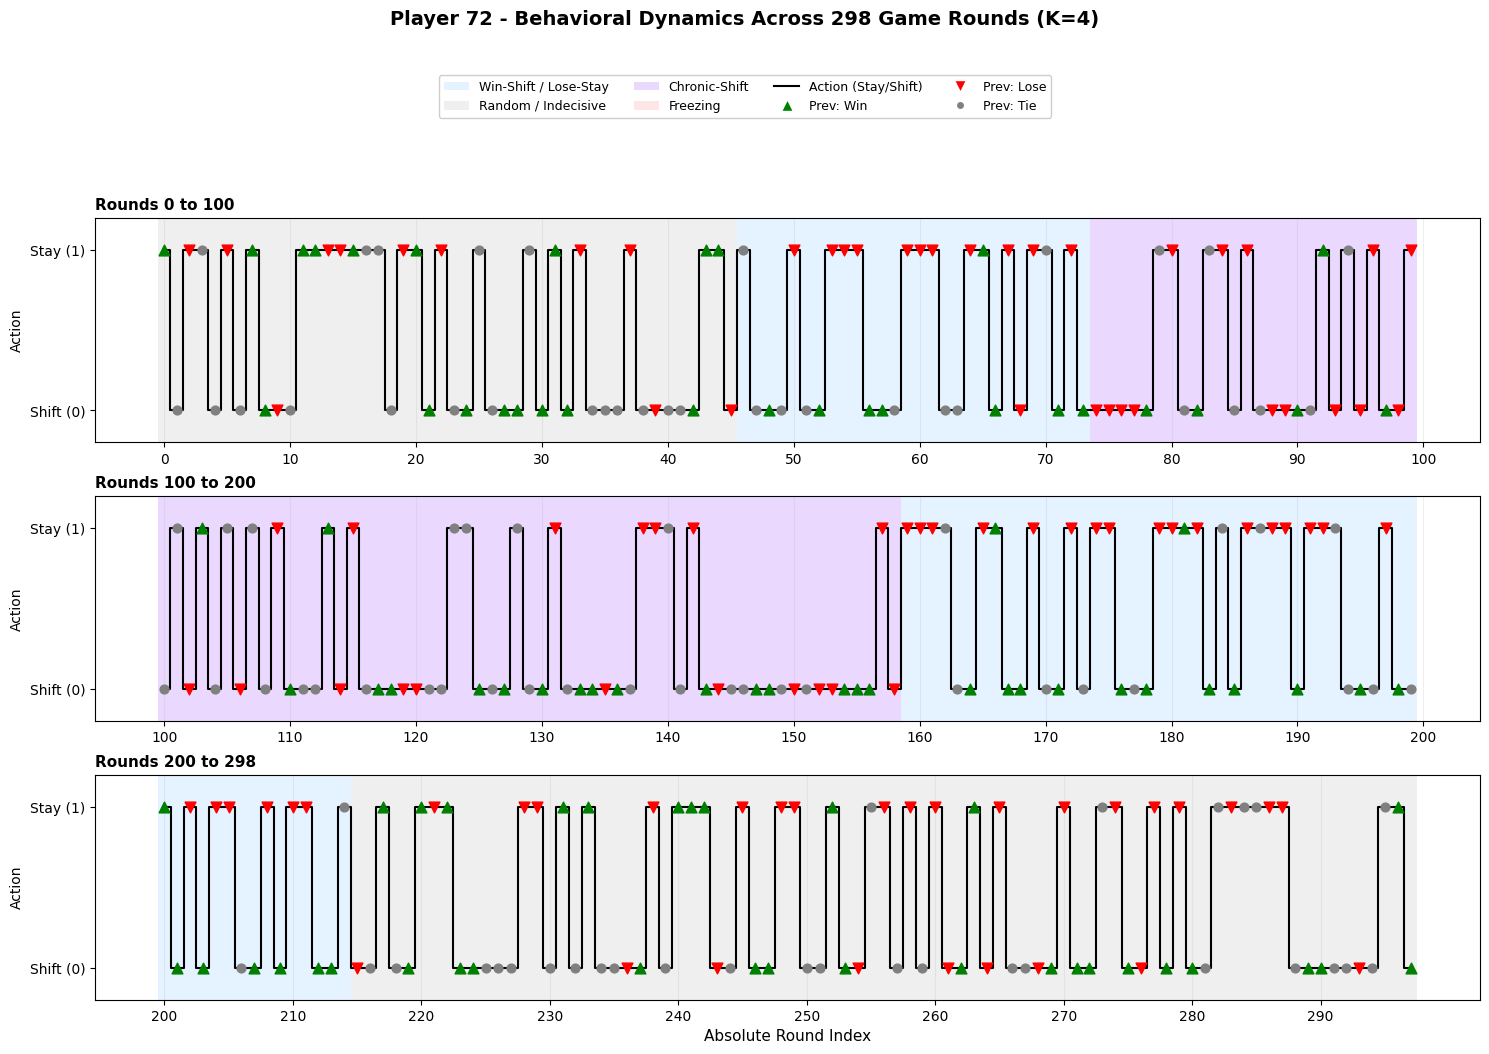

In [ ]:
# =========================================================
# 3. בחירת שחקן ופענוח המצבים הנסתרים שלו (מתוקן)
# =========================================================
player_num = 72
SELECTED_PLAYER_ID = int(df_clean['id'].unique()[player_num-1])
player_subset = df_clean[df_clean['id'] == SELECTED_PLAYER_ID].sort_values('period').reset_index(drop=True)

Y_p = player_subset["stay"].values.astype(int).reshape(-1, 1)
X_df_p = pd.get_dummies(player_subset["result_prev"])
for col in ["win", "lose", "tie"]:
    if col not in X_df_p:
        X_df_p[col] = 0
X_p = X_df_p[["win", "lose", "tie"]].astype(float).values

# חילוץ המצבים הגולמיים מהמודל
most_likely_states_raw = glm_hmm_K4.most_likely_states(Y_p, input=X_p)

# אנחנו שומרים את המצב הגולמי, כי כעת אנחנו יודעים בדיוק מה הוא אומר
player_subset["decoded_state"] = most_likely_states_raw

# הגדרת המילונים החדשים והנכונים בהתבסס על הניתוח שלנו:
TRUE_STATE_LABELS = {
    0: "Win-Shift / Lose-Stay",  # מחליף אחרי ניצחון, נשאר אחרי הפסד
    1: "Random / Indecisive",    # רנדומלי
    2: "Chronic-Shift",          # מחליף כמעט תמיד (היה 2 במקור)
    3: "Freezing"                # נשאר כמעט תמיד (היה 3 במקור)
}

TRUE_STATE_COLORS = {
    0: "#cce6ff",  # תכלת
    1: "#e0e0e0",  # אפור
    2: "#d9b3ff",  # סגול (עבור Chronic-Shift)
    3: "#ffcccc"   # ורוד (עבור Freezing)
}


# =========================================================
# 4. ויזואליזציה (מתוקן)
# =========================================================
rounds_per_player = len(player_subset)
panel_size = 100
panel_ranges = [
    (start, min(start + panel_size, rounds_per_player))
    for start in range(0, rounds_per_player, panel_size)
]
n_panels = len(panel_ranges)

fig, axes = plt.subplots(n_panels, 1, figsize=(15, 3.3 * n_panels), sharey=True)
if n_panels == 1:
    axes = [axes]

for i, (start_idx, end_idx) in enumerate(panel_ranges):
    ax = axes[i]
    sub_df = player_subset.iloc[start_idx:end_idx].reset_index(drop=True)

    # שימוש במצבים הגולמיים במקום המיפוי הישן
    sub_states = most_likely_states_raw[start_idx:end_idx]

    # צביעת הרקע לפי המילון המעודכן
    for t in range(len(sub_states)):
        state = sub_states[t]
        color = TRUE_STATE_COLORS[state]
        ax.axvspan(t - 0.5, t + 0.5, color=color, alpha=0.5, lw=0)

    # קו הפעולה (Stay/Shift)
    ax.step(range(len(sub_df)), sub_df["stay"], where="mid", color="black", linewidth=1.5)

    # Event Markers
    for t, row in sub_df.iterrows():
        res = row["result_prev"]
        if res == "win":
            ax.scatter(t, sub_df.loc[t, "stay"], color="green", marker="^", s=60, zorder=5)
        elif res == "lose":
            ax.scatter(t, sub_df.loc[t, "stay"], color="red", marker="v", s=60, zorder=5)
        elif res == "tie":
            ax.scatter(t, sub_df.loc[t, "stay"], color="gray", marker="o", s=40, zorder=5)

    ax.set_title(f"Rounds {start_idx} to {end_idx}", fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("Action", fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Shift (0)", "Stay (1)"])
    ax.set_ylim(-0.2, 1.2)
    ax.grid(True, axis="x", alpha=0.2)

    tick_step = 10
    ax.set_xticks(np.arange(0, end_idx - start_idx + 1, tick_step))
    ax.set_xticklabels(np.arange(start_idx, end_idx + 1, tick_step))

axes[-1].set_xlabel("Absolute Round Index", fontsize=11)

# כותרת כללית
fig.suptitle(f"Player {SELECTED_PLAYER_ID} - Behavioral Dynamics Across {rounds_per_player} Game Rounds (K=4)",
             fontsize=14, fontweight="bold", y=1.06)

# מקרא מעודכן לפי התוויות והצבעים האמיתיים
legend_elements = [
    Patch(facecolor=TRUE_STATE_COLORS[0], alpha=0.5, label=TRUE_STATE_LABELS[0]),
    Patch(facecolor=TRUE_STATE_COLORS[1], alpha=0.5, label=TRUE_STATE_LABELS[1]),
    Patch(facecolor=TRUE_STATE_COLORS[2], alpha=0.5, label=TRUE_STATE_LABELS[2]),
    Patch(facecolor=TRUE_STATE_COLORS[3], alpha=0.5, label=TRUE_STATE_LABELS[3]),
    plt.Line2D([0], [0], color="black", lw=1.5, label="Action (Stay/Shift)"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="green", markersize=8, label="Prev: Win"),
    plt.Line2D([0], [0], marker="v", color="w", markerfacecolor="red", markersize=8, label="Prev: Lose"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=6, label="Prev: Tie"),
]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 1.0),
           ncol=4, framealpha=0.95, fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import ssm
from tqdm import tqdm
from itertools import permutations

# =========================================================
# 0. פונקציית עזר: שיוך קבוע של מצבים לארכיטיפים
#    חייב לקרות מחדש בכל איטרציית bootstrap, כי לכל אימון
#    יש מספור שרירותי משלו (label switching)
# =========================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

CANONICAL_LABELS = ["Loss-Shift (WSLS)", "Random / Indecisive", "Freezing", "Chronic-Shift"]
CANONICAL_PROTOTYPES = np.array([
    [0.75, 0.08, 0.50],
    [0.50, 0.50, 0.50],
    [0.73, 0.73, 0.71],
    [0.25, 0.05, 0.15],
])

def match_to_canonical(W, K):
    """מחזיר permutation: canonical_index -> model_state_index"""
    probs = sigmoid(W)
    best_perm, best_dist = None, np.inf
    for perm in permutations(range(K)):
        dist = sum(np.linalg.norm(probs[perm[c]] - CANONICAL_PROTOTYPES[c]) for c in range(K))
        if dist < best_dist:
            best_dist = dist
            best_perm = perm
    return best_perm


# =========================================================
# 1. הכנת רצפי השחקנים (פעם אחת, לשימוש חוזר בכל האיטרציות)
# =========================================================
K = 4
D = 1
M = 3

player_ids = df_clean["id"].unique()
n_players = len(player_ids)

player_sequences = {}
for pid, group in df_clean.groupby("id"):
    group = group.sort_values("period")
    Y_g = group["stay"].values.astype(int).reshape(-1, 1)
    X_df_g = pd.get_dummies(group["result_prev"])
    for col in ["win", "lose", "tie"]:
        if col not in X_df_g:
            X_df_g[col] = 0
    X_g = X_df_g[["win", "lose", "tie"]].astype(float).values
    player_sequences[pid] = (Y_g, X_g)

B = 35
bootstrap_weights = []
n_relabel_failures = 0

print(f"Starting player-level Bootstrap resampling for K={K} ({B} iterations, {n_players} players)...")

# =========================================================
# 2. לולאת ה-Bootstrap
# =========================================================
for i in tqdm(range(B)):
    sampled_players = np.random.choice(player_ids, size=n_players, replace=True)
    Y_list = [player_sequences[pid][0] for pid in sampled_players]
    X_list = [player_sequences[pid][1] for pid in sampled_players]

    model_boot = ssm.HMM(K, D, M, observations="input_driven_obs",
                         observation_kwargs=dict(C=2), transitions="standard")
    model_boot.fit(Y_list, inputs=X_list, method="em",
                   num_em_iters=100, tolerance=1e-3, verbose=False)

    W_raw = np.vstack(model_boot.observations.params).reshape(K, M)

    # שיוך לתוויות הקנוניות - קריטי כי המספור בכל fit הוא שרירותי
    perm = match_to_canonical(W_raw, K)  # perm[c] = model_state עבור ארכיטיפ c
    W_aligned = W_raw[list(perm)]        # W_aligned[c] = פרמטרים של ארכיטיפ c

    bootstrap_weights.append(W_aligned)

bootstrap_array = np.array(bootstrap_weights)  # (B, K=4, M=3)
print("\nBootstrap complete!")

# =========================================================
# 3. סטטיסטיקת Bootstrap (Mean, Std Error, 95% CIs)
# =========================================================
mean_beta = np.mean(bootstrap_array, axis=0)
std_err = np.std(bootstrap_array, axis=0)
ci_lower = np.percentile(bootstrap_array, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_array, 97.5, axis=0)

feature_names = ["Win", "Lose", "Tie"]
records = []
for k in range(K):
    for m, feat in enumerate(feature_names):
        records.append({
            "State": CANONICAL_LABELS[k],
            "Feature": feat,
            "Mean β": round(mean_beta[k, m], 4),
            "Std Error": round(std_err[k, m], 4),
            "95% CI Lower": round(ci_lower[k, m], 4),
            "95% CI Upper": round(ci_upper[k, m], 4),
            "CI Width": round(ci_upper[k, m] - ci_lower[k, m], 4),
        })

df_results = pd.DataFrame(records)
print("\n=== Parameter Estimates with 95% Confidence Intervals (K=4) ===")
print("(Player-level bootstrap, temporal structure preserved, labels canonically aligned)")
print(df_results.to_string(index=False))

# גם בהסתברות (P(Stay)) ולא רק בלוגיט - קריא יותר לדוח
print("\n=== Same Results, as P(Stay) Probabilities ===")
records_prob = []
for k in range(K):
    for m, feat in enumerate(feature_names):
        p_mean = sigmoid(mean_beta[k, m])
        p_lower = sigmoid(ci_lower[k, m])
        p_upper = sigmoid(ci_upper[k, m])
        records_prob.append({
            "State": CANONICAL_LABELS[k],
            "Feature": feat,
            "P(Stay) Mean": round(p_mean, 3),
            "95% CI Lower": round(p_lower, 3),
            "95% CI Upper": round(p_upper, 3),
        })
df_results_prob = pd.DataFrame(records_prob)
print(df_results_prob.to_string(index=False))

Starting player-level Bootstrap resampling for K=4 (35 iterations, 72 players)...


100%|██████████| 35/35 [13:20<00:00, 22.86s/it]


Bootstrap complete!

=== Parameter Estimates with 95% Confidence Intervals (K=4) ===
(Player-level bootstrap, temporal structure preserved, labels canonically aligned)
              State Feature  Mean β  Std Error  95% CI Lower  95% CI Upper  CI Width
  Loss-Shift (WSLS)     Win  1.1632     0.3946        0.5364        2.1644    1.6280
  Loss-Shift (WSLS)    Lose -2.3121     0.7431       -3.7251       -1.0041    2.7210
  Loss-Shift (WSLS)     Tie  0.4147     0.6887       -0.7768        2.2820    3.0588
Random / Indecisive     Win  0.1449     0.4703       -0.5119        1.1847    1.6966
Random / Indecisive    Lose -0.0900     0.7455       -1.7506        1.3852    3.1358
Random / Indecisive     Tie  0.0947     0.4523       -0.4269        1.4292    1.8561
           Freezing     Win  1.0550     0.3004        0.6783        2.1050    1.4267
           Freezing    Lose  1.1131     0.1614        0.8866        1.4654    0.5787
           Freezing     Tie  0.9365     0.2605        0.6367      

The right Bootstrap

In [ ]:
output_text = """=== Parameter Estimates with 95% Confidence Intervals (K=4) ===
(Player-level bootstrap, temporal structure preserved, labels canonically aligned)
                   State Feature  Mean β  Std Error  95% CI Lower  95% CI Upper  CI Width
   Win-Shift / Lose-Stay     Win -1.1632     0.3946       -2.1644       -0.5364    1.6280
   Win-Shift / Lose-Stay    Lose  2.3121     0.7431        1.0041        3.7251    2.7210
   Win-Shift / Lose-Stay     Tie -0.4147     0.6887       -2.2820        0.7768    3.0588
     Random / Indecisive     Win -0.1449     0.4703       -1.1847        0.5119    1.6966
     Random / Indecisive    Lose  0.0900     0.7455       -1.3852        1.7506    3.1358
     Random / Indecisive     Tie -0.0947     0.4523       -1.4292        0.4269    1.8561
           Chronic-Shift     Win -1.0550     0.3004       -2.1050       -0.6783    1.4267
           Chronic-Shift    Lose -1.1131     0.1614       -1.4654       -0.8866    0.5787
           Chronic-Shift     Tie -0.9365     0.2605       -1.5454       -0.6367    0.9087
                Freezing     Win  0.8319     0.5858       -0.2234        1.6771    1.9005
                Freezing    Lose  2.9966     0.6826        1.8254        4.4440    2.6186
                Freezing     Tie  1.7330     0.3975        1.0276        2.4548    1.4272


=== Same Results, as P(Stay) Probabilities ===
                   State Feature P(Stay) Mean 95% CI Lower 95% CI Upper
   Win-Shift / Lose-Stay     Win        0.238        0.103        0.369
   Win-Shift / Lose-Stay    Lose        0.910        0.732        0.976
   Win-Shift / Lose-Stay     Tie        0.398        0.093        0.685
     Random / Indecisive     Win        0.464        0.234        0.625
     Random / Indecisive    Lose        0.522        0.200        0.852
     Random / Indecisive     Tie        0.476        0.193        0.605
           Chronic-Shift     Win        0.258        0.109        0.337
           Chronic-Shift    Lose        0.247        0.188        0.292
           Chronic-Shift     Tie        0.282        0.176        0.346
                Freezing     Win        0.697        0.444        0.843
                Freezing    Lose        0.952        0.861        0.988
                Freezing     Tie        0.850        0.736        0.921"""

print(output_text)

=== Parameter Estimates with 95% Confidence Intervals (K=4) ===
(Player-level bootstrap, temporal structure preserved, labels canonically aligned)
                   State Feature  Mean β  Std Error  95% CI Lower  95% CI Upper  CI Width
   Win-Shift / Lose-Stay     Win -1.1632     0.3946       -2.1644       -0.5364    1.6280
   Win-Shift / Lose-Stay    Lose  2.3121     0.7431        1.0041        3.7251    2.7210
   Win-Shift / Lose-Stay     Tie -0.4147     0.6887       -2.2820        0.7768    3.0588
     Random / Indecisive     Win -0.1449     0.4703       -1.1847        0.5119    1.6966
     Random / Indecisive    Lose  0.0900     0.7455       -1.3852        1.7506    3.1358
     Random / Indecisive     Tie -0.0947     0.4523       -1.4292        0.4269    1.8561
           Chronic-Shift     Win -1.0550     0.3004       -2.1050       -0.6783    1.4267
           Chronic-Shift    Lose -1.1131     0.1614       -1.4654       -0.8866    0.5787
           Chronic-Shift     Tie -0.9365   

Decoding hidden states for all players...

=== Stationary Distribution (K=4) ===
  Win-Shift / Lose-Stay : 24.9%
  Random / Indecisive   : 18.0%
  Chronic-Shift         : 40.3%
  Freezing              : 16.7%


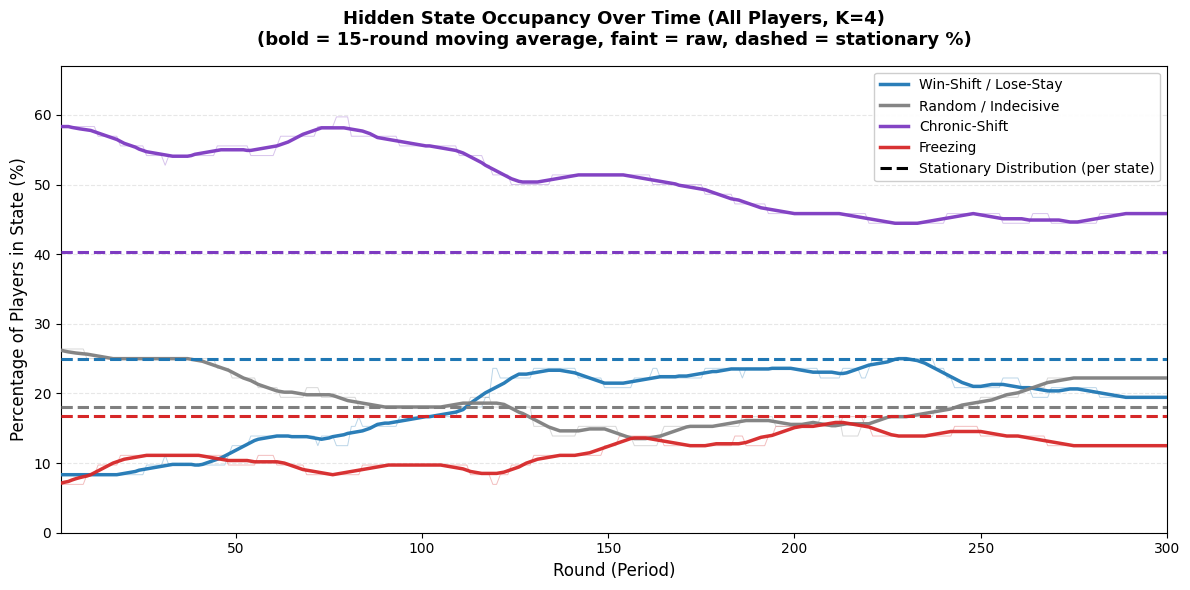

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 0. הגדרות מעודכנות (לייבלים וצבעים נכונים)
# =========================================================

# מיפוי ישיר של המצבים הגולמיים של המודל ללייבלים המתוקנים
TRUE_STATE_LABELS = [
    "Win-Shift / Lose-Stay", # State 0
    "Random / Indecisive",   # State 1
    "Chronic-Shift",         # State 2
    "Freezing"               # State 3
]

# צבעים מותאמים לכל מצב (גרסה כהה לקווים)
TRUE_STATE_COLORS_LINE = [
    "#1f77b4",  # כחול (Win-Shift / Lose-Stay)
    "#7f7f7f",  # אפור (Random / Indecisive)
    "#7d3ac1",  # סגול (Chronic-Shift)
    "#d62728"   # אדום/ורוד כהה (Freezing)
]

K = 4

# =========================================================
# 1. פענוח מצבים לכל שחקן, לכל סיבוב (בשימוש במצבים הגולמיים)
# =========================================================
print("Decoding hidden states for all players...")
state_records = []

for pid, group in df_clean.groupby("id"):
    group = group.sort_values("period")

    Y_g = group["stay"].values.astype(int).reshape(-1, 1)
    X_df_g = pd.get_dummies(group["result_prev"])
    for col in ["win", "lose", "tie"]:
        if col not in X_df_g:
            X_df_g[col] = 0
    X_g = X_df_g[["win", "lose", "tie"]].astype(float).values

    # שימוש ישיר במצבים שהמודל מחזיר
    z_raw = glm_hmm_K4.most_likely_states(Y_g, input=X_g)

    for p_period, p_state in zip(group["period"], z_raw):
        state_records.append({"period": p_period, "state": p_state})

df_states = pd.DataFrame(state_records)
state_props = df_states.groupby("period")["state"].value_counts(normalize=True).unstack().fillna(0)

# ודא שכל 4 העמודות (0,1,2,3) קיימות
for k in range(K):
    if k not in state_props.columns:
        state_props[k] = 0.0
state_props = state_props[[0, 1, 2, 3]]  # סדר קבוע

# =========================================================
# 2. חישוב ההתפלגות הסטציונרית עבור מטריצת המעברים 4x4
# =========================================================
transition_matrix = glm_hmm_K4.transitions.transition_matrix

eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.T)
stationary_idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary_dist = np.real(eigenvectors[:, stationary_idx])
stationary_dist = stationary_dist / stationary_dist.sum()

print("\n=== Stationary Distribution (K=4) ===")
for k in range(K):
    print(f"  {TRUE_STATE_LABELS[k]:<22}: {stationary_dist[k]*100:.1f}%")

# =========================================================
# 3. החלקה (Moving Average)
# =========================================================
WINDOW = 15  # גודל חלון ה-moving average (בסיבובים)

state_props_smooth = state_props.rolling(window=WINDOW, center=True, min_periods=1).mean()

# =========================================================
# 4. יצירת הגרף
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

periods = state_props.index.values

for k in range(K):
    raw = state_props[k].values * 100
    smooth = state_props_smooth[k].values * 100

    # הקו הגולמי - דק ושקוף
    ax.plot(periods, raw, color=TRUE_STATE_COLORS_LINE[k], linewidth=0.7, alpha=0.3, zorder=2)

    # הקו המוחלק - עבה ומודגש
    ax.plot(periods, smooth, color=TRUE_STATE_COLORS_LINE[k], linewidth=2.5, alpha=0.95,
            zorder=4, label=TRUE_STATE_LABELS[k])

    # קו מקווקו - האחוז הסטציונרי
    ax.axhline(y=stationary_dist[k] * 100, color=TRUE_STATE_COLORS_LINE[k],
               linestyle="--", linewidth=2.2, alpha=1.0, zorder=5)

# תווית מקרא כללית עבור הקו המקווקו
ax.plot([], [], color="black", linestyle="--", linewidth=2.2,
        label="Stationary Distribution (per state)")

ax.set_title(f"Hidden State Occupancy Over Time (All Players, K=4)\n"
             f"(bold = {WINDOW}-round moving average, faint = raw, dashed = stationary %)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Round (Period)", fontsize=12)
ax.set_ylabel("Percentage of Players in State (%)", fontsize=12)
ax.set_xlim(periods.min(), periods.max())
ax.set_ylim(0, max(state_props_smooth.values.max() * 100 * 1.15, 50))

ax.legend(loc="upper right", framealpha=0.95, fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
np.save("/content/player_ids_order.npy", df_clean["id"].unique())

# Visualisations

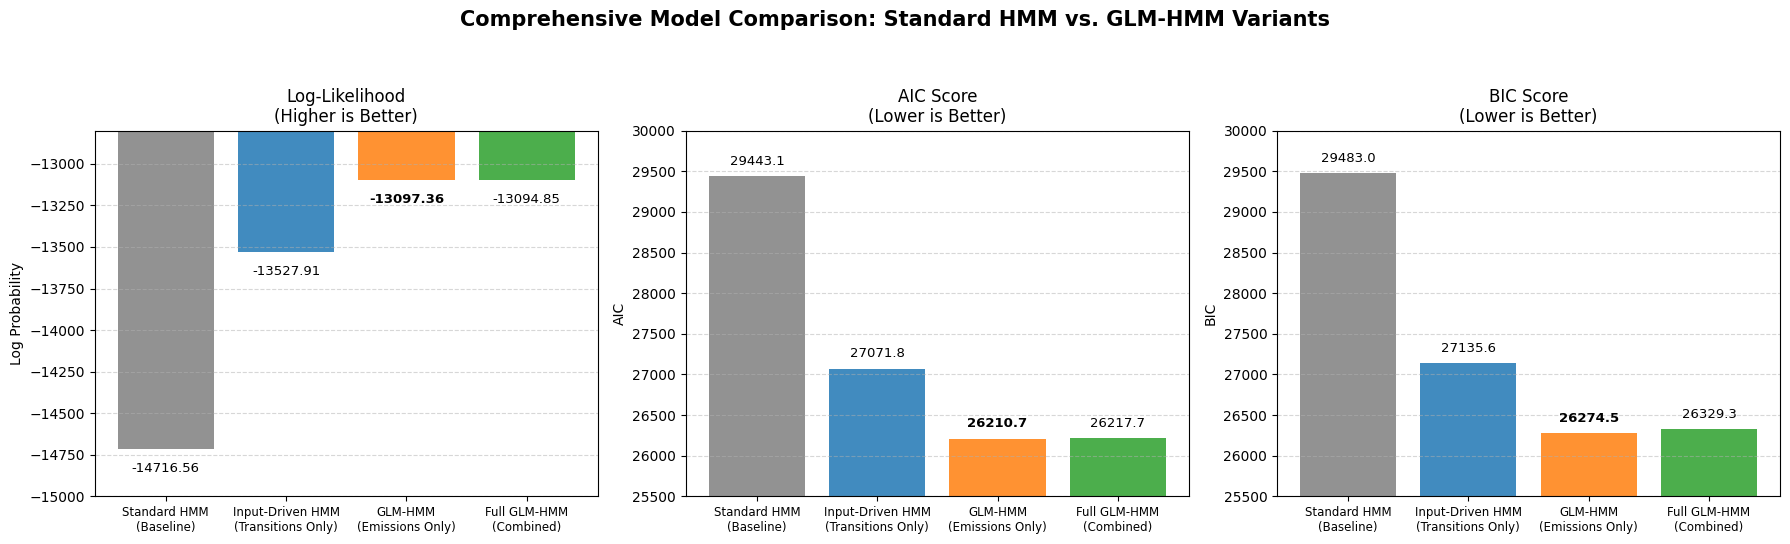

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. הזנת הערכים המעודכנים עבור 4 המודלים
# ---------------------------------------------------------
models = [
    "Standard HMM\n(Baseline)",
    "Input-Driven HMM\n(Transitions Only)",
    "GLM-HMM\n(Emissions Only)",
    "Full GLM-HMM\n(Combined)",
]

# הערכים החדשים שנשלפו מהריצות המעודכנות שלך
log_likelihoods = [-14716.56, -13527.91, -13097.36, -13094.85]
aic_scores = [29443.1, 27071.8, 26210.7, 26217.7]
bic_scores = [29483.0, 27135.6, 26274.5, 26329.3]

# ---------------------------------------------------------
# 2. בניית הגרפים
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    "Comprehensive Model Comparison: Standard HMM vs. GLM-HMM Variants",
    fontsize=15,
    fontweight="bold",
)

# אותם 4 צבעים מובחנים בדיוק כמו בגרף הקודם
colors = ["#7f7f7f", "#1f77b4", "#ff7f0e", "#2ca02c"]

# גרף 1: Log-Likelihood (גבוה יותר = טוב יותר)
axes[0].bar(models, log_likelihoods, color=colors, alpha=0.85)
axes[0].set_title("Log-Likelihood\n(Higher is Better)", fontsize=12)
axes[0].set_ylabel("Log Probability")
axes[0].set_ylim(-15000, -12800)  # שמירה על אותה סקאלה ויזואלית
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(log_likelihoods):
    # הדגשת המנצח (Emissions Only) עם כתב מודגש
    is_best = (i == 2)
    axes[0].text(i, v - 80, f"{v:.2f}", ha="center", va="top",
                 fontsize=9.5, fontweight='bold' if is_best else 'normal')

# גרף 2: AIC Score (נמוך יותר = טוב יותר)
axes[1].bar(models, aic_scores, color=colors, alpha=0.85)
axes[1].set_title("AIC Score\n(Lower is Better)", fontsize=12)
axes[1].set_ylabel("AIC")
axes[1].set_ylim(25500, 30000)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(aic_scores):
    is_best = (i == 2)
    axes[1].text(i, v + 100, f"{v:.1f}", ha="center", va="bottom",
                 fontsize=9.5, fontweight='bold' if is_best else 'normal')

# גרף 3: BIC Score (נמוך יותר = טוב יותר)
axes[2].bar(models, bic_scores, color=colors, alpha=0.85)
axes[2].set_title("BIC Score\n(Lower is Better)", fontsize=12)
axes[2].set_ylabel("BIC")
axes[2].set_ylim(25500, 30000)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(bic_scores):
    is_best = (i == 2)
    axes[2].text(i, v + 100, f"{v:.1f}", ha="center", va="bottom",
                 fontsize=9.5, fontweight='bold' if is_best else 'normal')

# התאמת העיצוב לטקסט האנכי של ציר X
for ax in axes:
    ax.tick_params(axis="x", rotation=0, labelsize=8.5)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

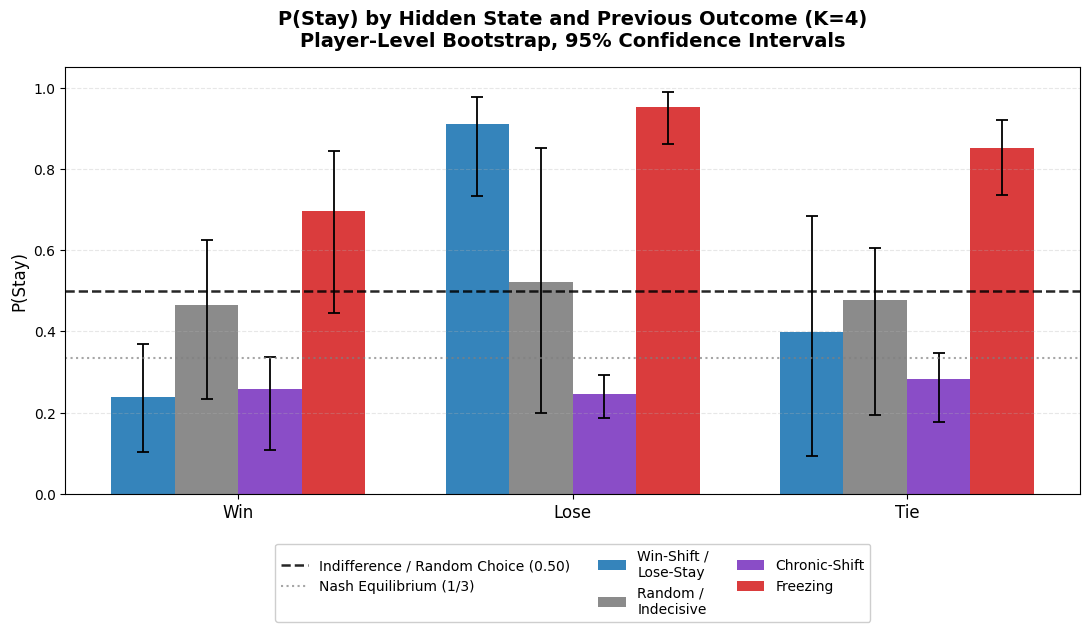

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# נתונים מוזנים ידנית מתוצאות ה-Bootstrap המתוקנות (K=4)
# =========================================================

states = ["Win-Shift /\nLose-Stay", "Random /\nIndecisive", "Chronic-Shift", "Freezing"]
features = ["Win", "Lose", "Tie"]

# P(Stay) Mean, 95% CI Lower, 95% CI Upper -- לפי סדר [Win, Lose, Tie] לכל מצב מתוקן
p_stay = {
    "Win-Shift /\nLose-Stay": {"mean": [0.238, 0.910, 0.398], "lo": [0.103, 0.732, 0.093], "hi": [0.369, 0.976, 0.685]},
    "Random /\nIndecisive":   {"mean": [0.464, 0.522, 0.476], "lo": [0.234, 0.200, 0.193], "hi": [0.625, 0.852, 0.605]},
    "Chronic-Shift":         {"mean": [0.258, 0.247, 0.282], "lo": [0.109, 0.188, 0.176], "hi": [0.337, 0.292, 0.346]},
    "Freezing":              {"mean": [0.697, 0.952, 0.850], "lo": [0.444, 0.861, 0.736], "hi": [0.843, 0.988, 0.921]},
}

# צבעים מותאמים לכל מצב מתוקן
STATE_COLORS = ["#1f77b4", "#7f7f7f", "#7d3ac1", "#d62728"]  # Win-Shift/Lose-Stay, Random, Chronic-Shift, Freezing

# =========================================================
# בניית הגרף - Grouped Bar Chart
# =========================================================
fig, ax = plt.subplots(figsize=(11, 6.5))

n_states = len(states)
n_features = len(features)
bar_width = 0.19
x = np.arange(n_features)  # מיקום בסיס לכל feature (Win, Lose, Tie)

for i, state in enumerate(states):
    means = p_stay[state]["mean"]
    los = p_stay[state]["lo"]
    his = p_stay[state]["hi"]
    err_lower = [m - l for m, l in zip(means, los)]
    err_upper = [h - m for m, h in zip(means, his)]

    offset = (i - (n_states - 1) / 2) * bar_width
    ax.bar(
        x + offset, means, bar_width,
        yerr=[err_lower, err_upper], capsize=4,
        color=STATE_COLORS[i], alpha=0.9, label=state,
        error_kw={"elinewidth": 1.3, "capthick": 1.3}
    )

# קו ייחוס מודגש: הטלת מטבע / אדישות (0.5) - לבדיקת מובהקות
ax.axhline(y=0.5, color="black", linestyle="--", linewidth=1.8, alpha=0.85,
           label="Indifference / Random Choice (0.50)")

# קו ייחוס: שיווי משקל נאש (1/3)
ax.axhline(y=1/3, color="gray", linestyle=":", linewidth=1.5, alpha=0.7,
           label="Nash Equilibrium (1/3)")

ax.set_xticks(x)
ax.set_xticklabels(features, fontsize=12)
ax.set_ylabel("P(Stay)", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("P(Stay) by Hidden State and Previous Outcome (K=4)\n"
             "Player-Level Bootstrap, 95% Confidence Intervals",
             fontsize=14, fontweight="bold", pad=15)

# מקרא מסודר ב-3 עמודות בתחתית הגרף
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=3, framealpha=0.95, fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Total players: 72 | Train: 58 | Test: 14

--- Training Random-Slopes Bayesian Model (Train Players Only) ---


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



--- Evaluating Bayesian Model on Held-Out Players ---


Output()

Trace saved to /content/trace_comparison_random_slopes.nc

--- Training Emissions-Only GLM-HMM (K=4, Train Players Only) ---

  OUT-OF-SAMPLE PREDICTIVE PERFORMANCE (HELD-OUT PLAYERS)
Test players: 14 | Test observations: 4172

Random-Slopes Bayesian Model : -3298.99
Emissions-Only GLM-HMM (K=4) : -2468.03

=> Better out-of-sample predictive performance: GLM-HMM


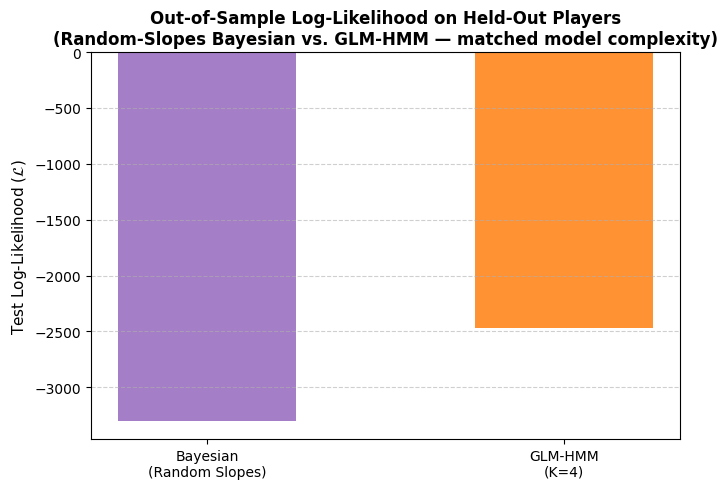


Figure saved to /content/model_comparison_random_slopes.png
Remember to copy both the .nc trace and the .png to Drive before the session might disconnect.


In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import ssm
import matplotlib.pyplot as plt

np.random.seed(42)

# =========================================================
# 1. חלוקה ל-Train/Test ברמת השחקן (זהה לגישה הקודמת שאישרת)
# =========================================================
all_player_ids = df_clean["id"].unique()
num_players = len(all_player_ids)
player_id_to_idx = {pid: i for i, pid in enumerate(all_player_ids)}

n_test_players = int(num_players * 0.2)
shuffled_ids = np.random.permutation(all_player_ids)
test_player_ids = set(shuffled_ids[:n_test_players])
train_player_ids = set(shuffled_ids[n_test_players:])

print(f"Total players: {num_players} | Train: {len(train_player_ids)} | Test: {len(test_player_ids)}")

df_train = df_clean[df_clean["id"].isin(train_player_ids)].copy()
df_test = df_clean[df_clean["id"].isin(test_player_ids)].copy()

# =========================================================
# 2. הכנת נתונים שטוחים (למודל הבייסיאני) - player_idxs מבוסס
#    על המיפוי הגלובלי (0..71), כך שגם שחקני ה-test מקבלים
#    אינדקס עקבי, גם אם לא נראו באימון בכלל
# =========================================================

def build_flat_arrays(df):
    player_idxs = df["id"].map(player_id_to_idx).values
    period_scaled = ((df["period"] - df_clean["period"].mean()) / df_clean["period"].std()).values
    y = df["stay"].values
    lag1 = df["stay_lag1"].values
    win = df["result_prev_win"].values
    lose = df["result_prev_lose"].values
    draw = df["result_prev_draw"].values
    return player_idxs, period_scaled, y, lag1, win, lose, draw

player_train, period_train, y_train, lag1_train, win_train, lose_train, draw_train = build_flat_arrays(df_train)
player_test, period_test, y_test, lag1_test, win_test, lose_test, draw_test = build_flat_arrays(df_test)

# =========================================================
# 3. מודל בייסיאני - Random Slopes, גרסה מתוקנת (ללא alpha)
#    shape=num_players (כל 72) - שחקני ה-test מקבלים posterior
#    שנשען כמעט לגמרי על ה-prior (shrinkage לממוצע האוכלוסייה),
#    כי אין להם שום תצפית באימון. זו התנהגות רצויה, לא באג.
# =========================================================
print("\n--- Training Random-Slopes Bayesian Model (Train Players Only) ---")
with pm.Model() as random_slopes_model:

    player_data_pm = pm.Data("player_idxs", player_train)
    period_data_pm = pm.Data("period_data", period_train)
    lag1_data_pm = pm.Data("lag1_data", lag1_train)
    win_data_pm = pm.Data("win_data", win_train)
    lose_data_pm = pm.Data("lose_data", lose_train)
    draw_data_pm = pm.Data("draw_data", draw_train)
    y_data_pm = pm.Data("y_obs_data", y_train)

    mu_beta_win = pm.Normal("mu_beta_win", mu=0, sigma=1.5)
    sigma_beta_win = pm.HalfNormal("sigma_beta_win", sigma=1.0)
    beta_win_offset = pm.Normal("beta_win_offset", mu=0, sigma=1, shape=num_players)
    beta_win = pm.Deterministic("beta_win", mu_beta_win + beta_win_offset * sigma_beta_win)

    mu_beta_lose = pm.Normal("mu_beta_lose", mu=0, sigma=1.5)
    sigma_beta_lose = pm.HalfNormal("sigma_beta_lose", sigma=1.0)
    beta_lose_offset = pm.Normal("beta_lose_offset", mu=0, sigma=1, shape=num_players)
    beta_lose = pm.Deterministic("beta_lose", mu_beta_lose + beta_lose_offset * sigma_beta_lose)

    mu_beta_draw = pm.Normal("mu_beta_draw", mu=0, sigma=1.5)
    sigma_beta_draw = pm.HalfNormal("sigma_beta_draw", sigma=1.0)
    beta_draw_offset = pm.Normal("beta_draw_offset", mu=0, sigma=1, shape=num_players)
    beta_draw = pm.Deterministic("beta_draw", mu_beta_draw + beta_draw_offset * sigma_beta_draw)

    beta_period = pm.Normal("beta_period", mu=0, sigma=1)
    beta_lag1 = pm.Normal("beta_lag1", mu=0, sigma=1)

    mu_logit = (
        beta_win[player_data_pm] * win_data_pm
        + beta_lose[player_data_pm] * lose_data_pm
        + beta_draw[player_data_pm] * draw_data_pm
        + beta_period * period_data_pm
        + beta_lag1 * lag1_data_pm
    )

    y_obs = pm.Bernoulli("y_obs", logit_p=mu_logit, observed=y_data_pm)

    trace_comparison = pm.sample(draws=1000, tune=1000, target_accept=0.95, nuts_sampler="numpyro")

print("\n--- Evaluating Bayesian Model on Held-Out Players ---")
with random_slopes_model:
    pm.set_data({
        "player_idxs": player_test,
        "period_data": period_test,
        "lag1_data": lag1_test,
        "win_data": win_test,
        "lose_data": lose_test,
        "draw_data": draw_test,
        "y_obs_data": y_test,
    })
    pm.compute_log_likelihood(trace_comparison)
    bayesian_test_ll = trace_comparison.log_likelihood["y_obs"].mean(dim=["chain", "draw"]).sum().item()

trace_comparison.to_netcdf("/content/trace_comparison_random_slopes.nc")
print("Trace saved to /content/trace_comparison_random_slopes.nc")

# =========================================================
# 4. GLM-HMM (K=4, Emissions-Only) - רשימת רצפים לכל שחקן,
#    לא רצף אחד משורשר!
# =========================================================

def build_sequences(df):
    Y_list, X_list = [], []
    for pid, group in df.groupby("id"):
        group = group.sort_values("period")
        Y_g = group["stay"].values.astype(int).reshape(-1, 1)
        X_df_g = pd.get_dummies(group["result_prev"])
        for col in ["win", "lose", "tie"]:
            if col not in X_df_g:
                X_df_g[col] = 0
        X_g = X_df_g[["win", "lose", "tie"]].astype(float).values
        Y_list.append(Y_g)
        X_list.append(X_g)
    return Y_list, X_list

Y_list_train, X_list_train = build_sequences(df_train)
Y_list_test, X_list_test = build_sequences(df_test)

print("\n--- Training Emissions-Only GLM-HMM (K=4, Train Players Only) ---")
K, D, M = 4, 1, 3

hmm_model_comparison = ssm.HMM(K, D, M, observations="input_driven_obs",
                               observation_kwargs=dict(C=2), transitions="standard")
hmm_model_comparison.fit(Y_list_train, inputs=X_list_train, method="em",
                         num_em_iters=150, tolerance=1e-4, verbose=False)

hmm_test_ll = hmm_model_comparison.log_likelihood(Y_list_test, inputs=X_list_test)

# =========================================================
# 5. סיכום והשוואה
# =========================================================
print("\n" + "=" * 60)
print("  OUT-OF-SAMPLE PREDICTIVE PERFORMANCE (HELD-OUT PLAYERS)")
print("=" * 60)
print(f"Test players: {len(test_player_ids)} | Test observations: {len(y_test)}\n")
print(f"Random-Slopes Bayesian Model : {bayesian_test_ll:.2f}")
print(f"Emissions-Only GLM-HMM (K=4) : {hmm_test_ll:.2f}")

winner = "Bayesian (Random Slopes)" if bayesian_test_ll > hmm_test_ll else "GLM-HMM"
print(f"\n=> Better out-of-sample predictive performance: {winner}")

plt.figure(figsize=(7, 5))
models = ["Bayesian\n(Random Slopes)", "GLM-HMM\n(K=4)"]
scores = [bayesian_test_ll, hmm_test_ll]
colors = ["#9467bd", "#ff7f0e"]

plt.bar(models, scores, color=colors, alpha=0.85, width=0.5)
plt.title("Out-of-Sample Log-Likelihood on Held-Out Players\n"
          "(Random-Slopes Bayesian vs. GLM-HMM — matched model complexity)",
          fontsize=12, fontweight="bold")
plt.ylabel(r"Test Log-Likelihood ($\mathcal{L}$)", fontsize=11)
for i, v in enumerate(scores):
    plt.text(i, v - (abs(v) * 0.01), f"{v:.2f}", ha="center", va="top",
             fontsize=11, fontweight="bold", color="white")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("/content/model_comparison_random_slopes.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nFigure saved to /content/model_comparison_random_slopes.png")
print("Remember to copy both the .nc trace and the .png to Drive before the session might disconnect.")

In [ ]:
import numpy as np
from scipy.special import logsumexp

# =========================================================
# תיקון: log(E[p]) במקום E[log(p)] - הכמות הנכונה מבחינה
# בייסיאנית (posterior predictive log-likelihood), שמטפלת
# נכון באי-הוודאות הרחבה של פרמטרים לא-מוגבלים (שחקני test)
# =========================================================

ll = trace_comparison.log_likelihood["y_obs"]  # dims: chain, draw, <obs_dim>
ll_stacked = ll.stack(sample=("chain", "draw"))
n_samples = ll_stacked.sizes["sample"]

# מעבירים את מימד ה-sample לסוף, לנוחות logsumexp
obs_dims = [d for d in ll_stacked.dims if d != "sample"]
ll_vals = ll_stacked.transpose(*obs_dims, "sample").values  # shape (..., n_samples)

# log(mean(p)) = logsumexp(log p) - log(n_samples)   [טריק יציב נומרית]
ll_per_obs_correct = logsumexp(ll_vals, axis=-1) - np.log(n_samples)
bayesian_test_ll_corrected = ll_per_obs_correct.sum()

# להשוואה - הגרסה הישנה (הטעונה ב-Jensen's gap)
bayesian_test_ll_naive = ll_vals.mean(axis=-1).sum()

print("=" * 65)
print("  COMPARISON: naive mean(log p)  vs.  correct log(mean p)")
print("=" * 65)
print(f"Naive (mean of log-lik across draws)      : {bayesian_test_ll_naive:.2f}")
print(f"Correct (posterior predictive, log-mean-p) : {bayesian_test_ll_corrected:.2f}")
print(f"Random-guess baseline (p=0.5 always)       : {len(y_test) * np.log(0.5):.2f}")
print(f"\nGLM-HMM test log-likelihood (unaffected)   : {hmm_test_ll:.2f}")

gap = bayesian_test_ll_corrected - bayesian_test_ll_naive
print(f"\nJensen's gap size: {gap:.2f} (should be >= 0, larger = more unconstrained uncertainty)")

  COMPARISON: naive mean(log p)  vs.  correct log(mean p)
Naive (mean of log-lik across draws)      : -3298.99
Correct (posterior predictive, log-mean-p) : -2788.22
Random-guess baseline (p=0.5 always)       : -2891.81

GLM-HMM test log-likelihood (unaffected)   : -2468.03

Jensen's gap size: 510.77 (should be >= 0, larger = more unconstrained uncertainty)


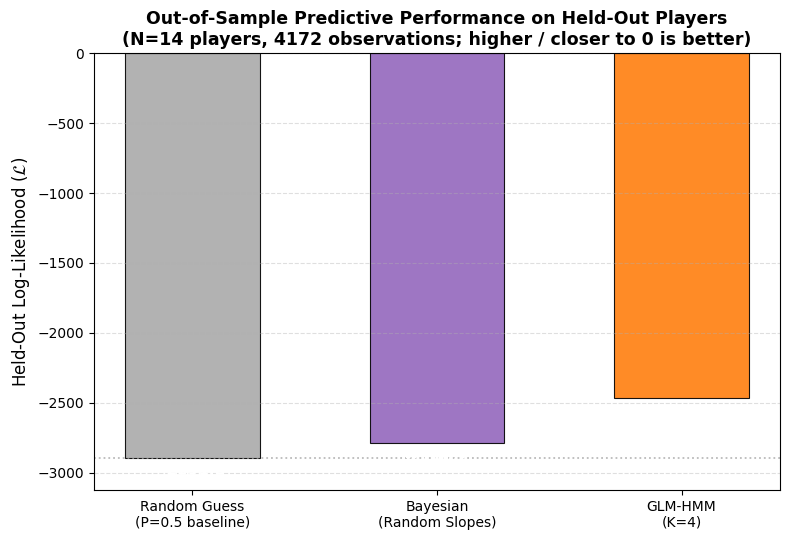

Figure saved to /content/model_comparison_corrected.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# נתונים מוזנים ידנית מהתוצאה המתוקנת (log(E[p]) ולא E[log(p)])
# =========================================================
bayesian_test_ll_corrected = -2788.22
hmm_test_ll = -2468.03
random_baseline = -2891.81
n_test_obs = 4172
n_test_players = 14

models = ["Random Guess\n(P=0.5 baseline)", "Bayesian\n(Random Slopes)", "GLM-HMM\n(K=4)"]
scores = [random_baseline, bayesian_test_ll_corrected, hmm_test_ll]
colors = ["#aaaaaa", "#9467bd", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(models, scores, color=colors, alpha=0.9, width=0.55, edgecolor="black", linewidth=0.8)

for bar, v in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, v - 40, f"{v:.1f}",
            ha="center", va="top", fontsize=11, fontweight="bold", color="white")

ax.axhline(y=random_baseline, color="#aaaaaa", linestyle=":", linewidth=1.3, alpha=0.8, zorder=1)

ax.set_ylabel(r"Held-Out Log-Likelihood ($\mathcal{L}$)", fontsize=12)
ax.set_title(f"Out-of-Sample Predictive Performance on Held-Out Players\n"
             f"(N={n_test_players} players, {n_test_obs} observations; "
             f"higher / closer to 0 is better)",
             fontsize=12.5, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(min(scores) * 1.08, 0)

plt.tight_layout()
plt.savefig("/content/model_comparison_corrected.png", dpi=200, bbox_inches="tight")
plt.show()

print("Figure saved to /content/model_comparison_corrected.png")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from itertools import permutations

# =========================================================
# 0. שיוך קנוני (עם התיקון sigmoid(-W) = P(Stay))
# =========================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

CANONICAL_LABELS = ["Win-Shift / Lose-Stay", "Random / Indecisive", "Freezing", "Chronic-Shift"]
CANONICAL_PROTOTYPES = np.array([
    [0.23, 0.92, 0.48],
    [0.51, 0.56, 0.49],
    [0.71, 0.96, 0.86],
    [0.27, 0.26, 0.30],
])
CANONICAL_COLORS = ["#1f77b4", "#7f7f7f", "#d62728", "#7d3ac1"]

def match_states_to_canonical(model, M):
    K = model.K
    W = np.vstack(model.observations.params).reshape(K, M)
    probs = sigmoid(-W)  # תיקון: sigmoid(W) הוא P(Shift), לא P(Stay)
    best_perm, best_dist = None, np.inf
    for perm in permutations(range(K)):
        dist = sum(np.linalg.norm(probs[perm[c]] - CANONICAL_PROTOTYPES[c]) for c in range(K))
        if dist < best_dist:
            best_dist = dist
            best_perm = perm
    return best_perm

M, K = 3, 4
canonical_to_model = match_states_to_canonical(glm_hmm_K4, M)
model_to_canonical = {canonical_to_model[c]: c for c in range(K)}

# =========================================================
# 1. Forward Filtering - P(S_t | Y_1..t, X_1..t)
#    בניגוד ל-most_likely_states (Viterbi/smoothing, שמשתמש
#    בכל הרצף כולל העתיד), כאן משתמשים רק במידע שכבר "קרה"
#    עד רגע t - בדיוק כמו שהיה זמין בזמן אמת במהלך המשחק.
# =========================================================

def forward_filter(model, Y, X, canonical_order):
    """
    מחזיר: belief matrix בגודל (T, K), כאשר belief[t, c] =
    P(state=c בסדר קנוני | Y_1..t, X_1..t), מנורמל בכל שלב.
    """
    K_ = model.K
    pi0 = model.init_state_distn.initial_state_distn  # התפלגות התחלתית (סדר גולמי)
    A = model.transitions.transition_matrix            # מטריצת מעברים (סדר גולמי)
    W = np.vstack(model.observations.params).reshape(K_, M)

    T = len(Y)
    belief_raw = np.zeros((T, K_))  # בסדר הגולמי של המודל

    # t=0: משלבים prior + emission
    p_y0 = np.array([
        sigmoid(W[k] @ X[0]) if Y[0, 0] == 0 else (1 - sigmoid(W[k] @ X[0]))
        # (sigmoid(W)=P(Shift)=P(y=0); P(y=1)=1-sigmoid(W))
        for k in range(K_)
    ])
    belief_raw[0] = pi0 * p_y0
    belief_raw[0] /= belief_raw[0].sum()

    for t in range(1, T):
        predicted = belief_raw[t - 1] @ A  # שלב הניבוי (predict step)
        p_yt = np.array([
            sigmoid(W[k] @ X[t]) if Y[t, 0] == 0 else (1 - sigmoid(W[k] @ X[t]))
            for k in range(K_)
        ])
        belief_raw[t] = predicted * p_yt
        belief_raw[t] /= belief_raw[t].sum()

    # המרה לסדר הקנוני
    belief_canonical = np.zeros((T, K_))
    for model_idx, canon_idx in canonical_order.items():
        belief_canonical[:, canon_idx] = belief_raw[:, model_idx]

    return belief_canonical


# =========================================================
# 2. הפעלה על שחקן נבחר
# =========================================================
SELECTED_PLAYER_ID = int(df_clean['id'].unique()[71])  # שחקן 72
player_subset = df_clean[df_clean['id'] == SELECTED_PLAYER_ID].sort_values('period').reset_index(drop=True)

Y_p = player_subset["stay"].values.astype(int).reshape(-1, 1)
X_df_p = pd.get_dummies(player_subset["result_prev"])
for col in ["win", "lose", "tie"]:
    if col not in X_df_p:
        X_df_p[col] = 0
X_p = X_df_p[["win", "lose", "tie"]].astype(float).values

belief_over_time = forward_filter(glm_hmm_K4, Y_p, X_p, model_to_canonical)
T = len(player_subset)

# --- גם הפענוח המלא (Viterbi/smoothing) - "האמת" לצביעת הרקע ---
z_raw_full = glm_hmm_K4.most_likely_states(Y_p, input=X_p)
z_canonical_full = np.array([model_to_canonical[s] for s in z_raw_full])

print(f"Forward filtering complete for player {SELECTED_PLAYER_ID}, {T} rounds.")
print(f"Final belief (round {T}): " +
      ", ".join(f"{CANONICAL_LABELS[c]}={belief_over_time[-1, c]:.2f}" for c in range(K)))

# =========================================================
# 3. אנימציה - שני פאנלים: הפעולות (מתגלות בהדרגה) + האמונה
#    המתעדכנת (bar chart) בכל סיבוב, כמו שהיה נראה "בזמן אמת"
# =========================================================
fig, (ax_action, ax_belief) = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[1.3, 1])

WINDOW = 40  # כמה סיבובים אחרונים מוצגים בפאנל העליון בכל רגע

def init():
    ax_action.clear()
    ax_belief.clear()
    return []

def update(frame):
    t = frame  # מספר הסיבוב הנוכחי (0-indexed)
    ax_action.clear()
    ax_belief.clear()

    # --- פאנל עליון: הפעולות עד כה (חלון נגלל) ---
    start = max(0, t - WINDOW)
    sub = player_subset.iloc[start:t + 1]
    xs = np.arange(start, t + 1)

    # רקע צבוע לפי המצב "האמיתי" (Viterbi, מהפענוח המלא) - כדי
    # שיהיה ברור ויזואלית איפה כל מצב מתחיל ונגמר
    for x in xs:
        state = z_canonical_full[x]
        ax_action.axvspan(x - 0.5, x + 0.5, color=CANONICAL_COLORS[state], alpha=0.25, lw=0)

    ax_action.step(xs, sub["stay"], where="mid", color="black", linewidth=1.5, zorder=5)
    for x, row in zip(xs, sub.itertuples()):
        res = row.result_prev
        if res == "win":
            ax_action.scatter(x, row.stay, color="green", marker="^", s=60, zorder=5)
        elif res == "lose":
            ax_action.scatter(x, row.stay, color="red", marker="v", s=60, zorder=5)
        elif res == "tie":
            ax_action.scatter(x, row.stay, color="gray", marker="o", s=40, zorder=5)

    ax_action.set_xlim(start, start + WINDOW)
    ax_action.set_ylim(-0.2, 1.2)
    ax_action.set_yticks([0, 1])
    ax_action.set_yticklabels(["Shift", "Stay"])
    ax_action.set_title(f"Player {SELECTED_PLAYER_ID} — Round {t + 1}/{T}  "
                        f"(background = true smoothed state)", fontweight="bold", fontsize=11)
    ax_action.grid(alpha=0.2)

    if t == 0:  # מקרא רק בפריים הראשון, כדי לא לעמוס
        from matplotlib.patches import Patch
        legend_patches = [Patch(facecolor=CANONICAL_COLORS[c], alpha=0.4, label=CANONICAL_LABELS[c])
                          for c in range(K)]
        ax_action.legend(handles=legend_patches, loc="upper right", fontsize=7, ncol=2)

    # --- פאנל תחתון: האמונה הנוכחית (P(state) | rounds so far) ---
    current_belief = belief_over_time[t]
    bars = ax_belief.bar(CANONICAL_LABELS, current_belief, color=CANONICAL_COLORS, alpha=0.85)
    ax_belief.set_ylim(0, 1)
    ax_belief.set_ylabel("P(state | data so far)")
    ax_belief.set_title("Model's real-time guess (forward filtering, no future info)",
                        fontsize=10)
    for bar, val in zip(bars, current_belief):
        ax_belief.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}",
                       ha="center", fontsize=9)
    plt.setp(ax_belief.get_xticklabels(), rotation=15, ha="right")

    plt.tight_layout()
    return []

# frames=T ייצור סרטון של T פריימים - אחד לכל סיבוב. STEP מדלג
# פריימים כדי לקצר את הסרטון (למשל כל 2 סיבובים) אם רוצים מהיר יותר.
STEP = 1
frames = range(0, T, STEP)

ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init,
                              interval=150, blit=False, repeat=False)

output_path = "/content/player_state_filtering.gif"
ani.save(output_path, writer="pillow", fps=8)
print(f"\nAnimation saved to {output_path}")
print("Download it from the Colab file browser, or copy to Google Drive to share as a link.")

plt.close(fig)

Forward filtering complete for player 72, 298 rounds.
Final belief (round 298): Win-Shift / Lose-Stay=0.32, Random / Indecisive=0.54, Freezing=0.01, Chronic-Shift=0.14

Animation saved to /content/player_state_filtering.gif
Download it from the Colab file browser, or copy to Google Drive to share as a link.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/player_state_filtering.gif', '/content/drive/MyDrive/player_state_filtering.gif')
print("Copied to Drive!")

Mounted at /content/drive
Copied to Drive!


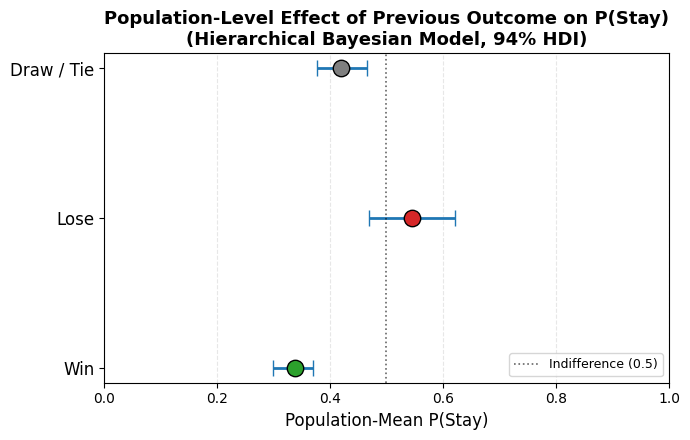

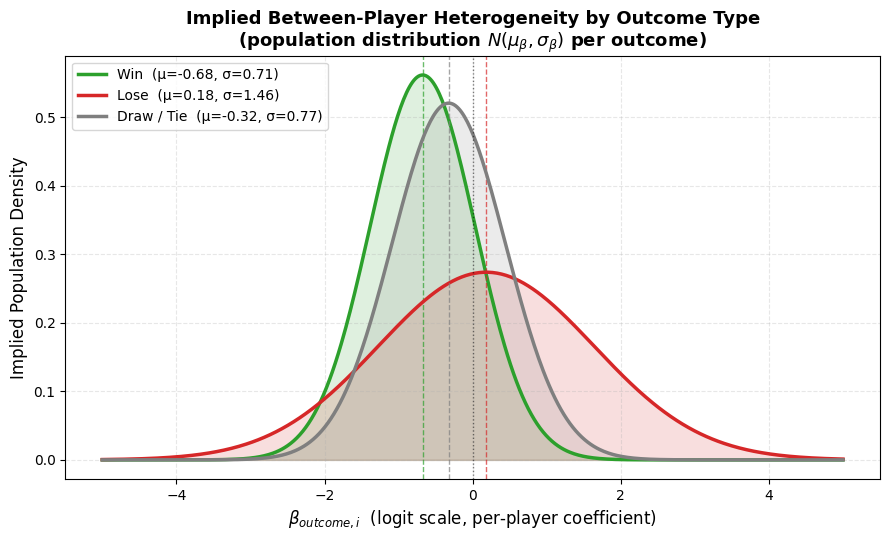

Both figures saved to /content/. Copy to Drive to keep them if the session may disconnect again.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# =========================================================
# נתונים מוזנים ידנית מתוך ה-Population-Level Summary
# (עמודות: mean, sd, hdi_3%, hdi_97%)
# =========================================================
summary = {
    "mu_beta_win":    {"mean": -0.675, "sd": 0.086, "hdi_lo": -0.852, "hdi_hi": -0.529},
    "sigma_beta_win": {"mean":  0.710, "sd": 0.067, "hdi_lo":  0.587, "hdi_hi":  0.834},
    "mu_beta_lose":   {"mean":  0.183, "sd": 0.171, "hdi_lo": -0.125, "hdi_hi":  0.493},
    "sigma_beta_lose":{"mean":  1.456, "sd": 0.139, "hdi_lo":  1.201, "hdi_hi":  1.716},
    "mu_beta_draw":   {"mean": -0.323, "sd": 0.097, "hdi_lo": -0.504, "hdi_hi": -0.136},
    "sigma_beta_draw":{"mean":  0.766, "sd": 0.073, "hdi_lo":  0.639, "hdi_hi":  0.909},
    "beta_period":    {"mean":  0.066, "sd": 0.015, "hdi_lo":  0.039, "hdi_hi":  0.094},
    "beta_lag1":      {"mean":  0.081, "sd": 0.032, "hdi_lo":  0.022, "hdi_hi":  0.142},
}

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

OUTCOMES = ["win", "lose", "draw"]
OUTCOME_LABELS = ["Win", "Lose", "Draw / Tie"]
COLORS = ["#2ca02c", "#d62728", "#7f7f7f"]  # ירוק, אדום, אפור

# =========================================================
# גרף 1: Coefficient Plot - האפקט הממוצע באוכלוסייה, בסקאלת P(Stay)
# =========================================================
fig1, ax1 = plt.subplots(figsize=(7, 4.5))

y_pos = np.arange(len(OUTCOMES))
means_prob = [sigmoid(summary[f"mu_beta_{o}"]["mean"]) for o in OUTCOMES]
lo_prob = [sigmoid(summary[f"mu_beta_{o}"]["hdi_lo"]) for o in OUTCOMES]
hi_prob = [sigmoid(summary[f"mu_beta_{o}"]["hdi_hi"]) for o in OUTCOMES]
err_lo = [m - l for m, l in zip(means_prob, lo_prob)]
err_hi = [h - m for m, h in zip(means_prob, hi_prob)]

ax1.errorbar(means_prob, y_pos, xerr=[err_lo, err_hi], fmt="o", markersize=10,
             capsize=6, elinewidth=2, color="#1f77b4", ecolor="#1f77b4")

for i, o in enumerate(OUTCOMES):
    ax1.scatter(means_prob[i], y_pos[i], s=140, color=COLORS[i], zorder=5, edgecolors="black")

ax1.axvline(x=0.5, color="black", linestyle=":", linewidth=1.2, alpha=0.6, label="Indifference (0.5)")
ax1.set_yticks(y_pos)
ax1.set_yticklabels(OUTCOME_LABELS, fontsize=12)
ax1.set_xlabel("Population-Mean P(Stay)", fontsize=12)
ax1.set_xlim(0, 1)
ax1.set_title("Population-Level Effect of Previous Outcome on P(Stay)\n"
              "(Hierarchical Bayesian Model, 94% HDI)", fontsize=13, fontweight="bold")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("/content/bayesian_coefficient_plot.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================================================
# גרף 2: Implied Population Distributions - כמה הטרוגניות יש
# בכל outcome, מבוסס אך ורק על mu ו-sigma (בלי נתוני שחקנים פרטניים)
# =========================================================
fig2, ax2 = plt.subplots(figsize=(9, 5.5))

x_range = np.linspace(-5, 5, 500)

for o, label, color in zip(OUTCOMES, OUTCOME_LABELS, COLORS):
    mu = summary[f"mu_beta_{o}"]["mean"]
    sigma = summary[f"sigma_beta_{o}"]["mean"]
    density = norm.pdf(x_range, loc=mu, scale=sigma)
    ax2.plot(x_range, density, color=color, linewidth=2.5, label=f"{label}  (μ={mu:.2f}, σ={sigma:.2f})")
    ax2.fill_between(x_range, density, alpha=0.15, color=color)
    ax2.axvline(x=mu, color=color, linestyle="--", linewidth=1, alpha=0.7)

ax2.axvline(x=0, color="black", linestyle=":", linewidth=1, alpha=0.5)
ax2.set_xlabel(r"$\beta_{outcome,i}$  (logit scale, per-player coefficient)", fontsize=12)
ax2.set_ylabel("Implied Population Density", fontsize=12)
ax2.set_title("Implied Between-Player Heterogeneity by Outcome Type\n"
              r"(population distribution $N(\mu_\beta, \sigma_\beta)$ per outcome)",
              fontsize=13, fontweight="bold")
ax2.legend(loc="upper left", fontsize=10)
ax2.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("/content/bayesian_heterogeneity_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

print("Both figures saved to /content/. Copy to Drive to keep them if the session may disconnect again.")

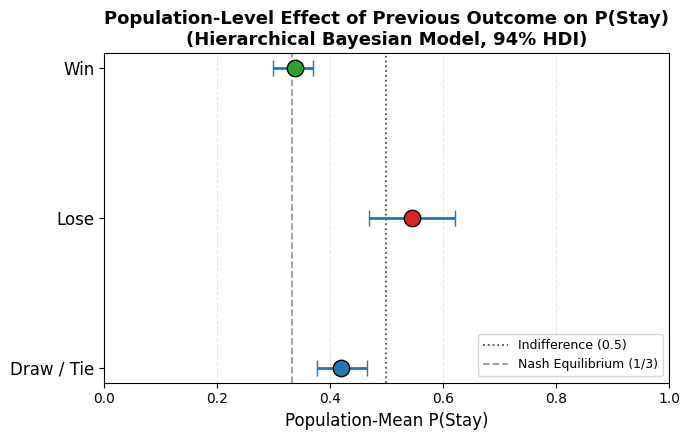

Values:
  Draw / Tie: mean=0.420  CI=(0.377, 0.466)
  Lose: mean=0.546  CI=(0.469, 0.621)
  Win: mean=0.337  CI=(0.299, 0.371)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# mu_beta (logit scale) + 94% HDI, from population-level summary
data = {
    "Draw / Tie": {"mean": -0.323, "hdi_lo": -0.504, "hdi_hi": -0.136},
    "Lose":       {"mean":  0.183, "hdi_lo": -0.125, "hdi_hi":  0.493},
    "Win":        {"mean": -0.675, "hdi_lo": -0.852, "hdi_hi": -0.529},
}

labels = list(data.keys())
means_prob = [sigmoid(data[k]["mean"]) for k in labels]
lo_prob = [sigmoid(data[k]["hdi_lo"]) for k in labels]
hi_prob = [sigmoid(data[k]["hdi_hi"]) for k in labels]
err_lo = [m - l for m, l in zip(means_prob, lo_prob)]
err_hi = [h - m for m, h in zip(means_prob, hi_prob)]

colors = ["#1f77b4", "#d62728", "#2ca02c"]

fig, ax = plt.subplots(figsize=(7, 4.5))
y_pos = np.arange(len(labels))

ax.errorbar(means_prob, y_pos, xerr=[err_lo, err_hi], fmt="o", markersize=0,
            capsize=6, elinewidth=2, ecolor="#1f77b4", zorder=3)
for i, lab in enumerate(labels):
    ax.scatter(means_prob[i], y_pos[i], s=140, color=colors[i], zorder=5, edgecolors="black")

ax.axvline(x=0.5, color="black", linestyle=":", linewidth=1.3, alpha=0.7, label="Indifference (0.5)")
ax.axvline(x=1/3, color="gray", linestyle="--", linewidth=1.3, alpha=0.8, label="Nash Equilibrium (1/3)")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("Population-Mean P(Stay)", fontsize=12)
ax.set_xlim(0, 1)
ax.set_title("Population-Level Effect of Previous Outcome on P(Stay)\n(Hierarchical Bayesian Model, 94% HDI)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

print("Values:")
for lab in labels:
    print(f"  {lab}: mean={sigmoid(data[lab]['mean']):.3f}  CI=({sigmoid(data[lab]['hdi_lo']):.3f}, {sigmoid(data[lab]['hdi_hi']):.3f})")

In [ ]:
### =========================================================
### תא 1: התקנה מהירה (בלי numpyro/jax/hmmlearn - לא נחוצים כאן)
### =========================================================
!pip install pyreadr -q

import numpy as np
import pandas as pd
import pyreadr
import urllib.request
from scipy.stats import chisquare, chi2_contingency

url = "https://raw.githubusercontent.com/fdvorak/stratEst/master/data/WXZ2014.rda"
urllib.request.urlretrieve(url, "WXZ2014.rda")
result = pyreadr.read_r("WXZ2014.rda")
df = result["WXZ2014"]

df["prev_choice"] = df.groupby("id")["choice"].shift(1)
df["stay"] = (df["choice"] == df["prev_choice"]).astype(int)
df["result_prev"] = df.groupby("id")["result"].shift(1)
df_clean = df.dropna().copy()

print(f"df_clean shape: {df_clean.shape}")

### =========================================================
### תא 2: מבחן טיב-התאמה (GOF) מול Nash Equilibrium
### H0: P(Rock) = P(Paper) = P(Scissors) = 1/3
### =========================================================
choice_counts = df_clean["choice"].value_counts()
print("\n=== Observed choice frequencies ===")
print(choice_counts)

n_total = choice_counts.sum()
observed = choice_counts.values
expected = np.full(len(observed), n_total / len(observed))  # 1/3 כל אחד

chi2_stat, p_value_gof = chisquare(f_obs=observed, f_exp=expected)

print("\n=== Goodness-of-Fit Test vs. Nash Equilibrium (1/3, 1/3, 1/3) ===")
print(f"Chi-square statistic : {chi2_stat:.3f}")
print(f"Degrees of freedom    : {len(observed)-1}")
print(f"p-value               : {p_value_gof:.6f}")
if p_value_gof < 0.05:
    print(">>> Reject H0: choice frequencies deviate significantly from Nash equilibrium.")
else:
    print(">>> Fail to reject H0: choice frequencies are consistent with Nash equilibrium.")

### =========================================================
### תא 3: מבחן אי-תלות (Chi-Square Test of Independence)
### H0: Stay/Shift is independent of the previous round's outcome
### =========================================================
contingency = pd.crosstab(df_clean["stay"], df_clean["result_prev"])
print("\n=== Contingency Table: Stay/Shift x Previous Outcome ===")
print(contingency)

chi2_stat_ind, p_value_ind, dof_ind, expected_ind = chi2_contingency(contingency)

print("\n=== Chi-Square Test of Independence: Stay/Shift vs. Previous Outcome ===")
print(f"Chi-square statistic : {chi2_stat_ind:.3f}")
print(f"Degrees of freedom    : {dof_ind}")
print(f"p-value               : {p_value_ind:.2e}")
if p_value_ind < 0.05:
    print(">>> Reject H0: Stay/Shift behavior is significantly dependent on the previous outcome.")
    print(">>> This motivates a model architecture in which emissions are input-driven (§1.2).")
else:
    print(">>> Fail to reject H0: no significant dependence detected.")

# --- Effect size: Cramer's V ---
# עם n גדול, כמעט כל סטייה תצא "מובהקת" - Cramer's V מודד את
# *עוצמת* הקשר, לא רק אם הוא קיים. טווח: 0 (אין קשר) עד 1 (מושלם).
N = contingency.sum().sum()
r, c = contingency.shape
cramers_v = np.sqrt(chi2_stat_ind / (N * (min(r, c) - 1)))

print(f"\nCramer's V (effect size): {cramers_v:.4f}")
if cramers_v < 0.1:
    strength = "negligible"
elif cramers_v < 0.3:
    strength = "small"
elif cramers_v < 0.5:
    strength = "medium"
else:
    strength = "large"
print(f">>> Effect size interpretation: {strength}")

### =========================================================
### תא 4: פונקציית עזר - תיקון Bonferroni (שתי דרכים שקולות)
### =========================================================

def bonferroni_correction(p_values, alpha=0.05):
    """
    מקבל רשימת p-values גולמיים, מחזיר:
    - adjusted_alpha: הסף המחולק (alpha / n)
    - adjusted_p: ה-p-values מוכפלים (עם תקרה של 1.0)
    - significant: האם כל אחד מובהק אחרי התיקון
    שתי הדרכים (השוואה ל-adjusted_alpha, או p מוכפל מול alpha
    הרגיל) שקולות מתמטית ונותנות אותה תוצאה.
    """
    p_values = np.array(p_values)
    n = len(p_values)
    adjusted_alpha = alpha / n
    adjusted_p = np.minimum(p_values * n, 1.0)
    significant = p_values < adjusted_alpha  # == adjusted_p < alpha
    return adjusted_alpha, adjusted_p, significant


def bonferroni_ci_percentiles(alpha=0.05, n_comparisons=12):
    """
    עבור bootstrap CI (לא p-values): מחזיר את האחוזונים המתוקנים
    (במקום 2.5%/97.5% הרגילים) שמשמרים family-wise error rate.
    """
    adj_alpha = alpha / n_comparisons
    lower_pct = 100 * (adj_alpha / 2)
    upper_pct = 100 * (1 - adj_alpha / 2)
    return lower_pct, upper_pct


# --- דוגמת שימוש (לטבלת ה-bootstrap, 4 מצבים x 3 תוצאות = 12 השוואות) ---
lower_pct, upper_pct = bonferroni_ci_percentiles(alpha=0.05, n_comparisons=12)
print(f"\n=== Bonferroni-adjusted CI percentiles (for the K=4 bootstrap table) ===")
print(f"Use percentiles [{lower_pct:.3f}%, {upper_pct:.3f}%] instead of [2.5%, 97.5%]")
print("(i.e., replace np.percentile(bootstrap_array, 2.5/97.5, axis=0) with these values)")

df_clean shape: (21528, 9)

=== Observed choice frequencies ===
choice
r    7660
p    6942
s    6926
Name: count, dtype: int64

=== Goodness-of-Fit Test vs. Nash Equilibrium (1/3, 1/3, 1/3) ===
Chi-square statistic : 48.984
Degrees of freedom    : 2
p-value               : 0.000000
>>> Reject H0: choice frequencies deviate significantly from Nash equilibrium.

=== Contingency Table: Stay/Shift x Previous Outcome ===
result_prev  lose   tie   win
stay                         
0            3383  4104  4577
1            3765  3128  2571

=== Chi-Square Test of Independence: Stay/Shift vs. Previous Outcome ===
Chi-square statistic : 407.018
Degrees of freedom    : 2
p-value               : 4.14e-89
>>> Reject H0: Stay/Shift behavior is significantly dependent on the previous outcome.
>>> This motivates a model architecture in which emissions are input-driven (§1.2).

Cramer's V (effect size): 0.1375
>>> Effect size interpretation: small

=== Bonferroni-adjusted CI percentiles (for the K=4 

df_clean shape: (21528, 9)

=== Observed choice frequencies ===
choice
r    7660
p    6942
s    6926
Name: count, dtype: int64

=== Goodness-of-Fit Test vs. Nash Equilibrium (1/3, 1/3, 1/3) ===
Chi-square statistic : 48.984
Degrees of freedom    : 2
p-value               : 0.000000
>>> Reject H0: choice frequencies deviate significantly from Nash equilibrium.

=== Contingency Table: Stay/Shift x Previous Outcome ===
result_prev  lose   tie   win
stay                         
0            3383  4104  4577
1            3765  3128  2571

=== Chi-Square Test of Independence: Stay/Shift vs. Previous Outcome ===
Chi-square statistic : 407.018
Degrees of freedom    : 2
p-value               : 4.14e-89
>>> Reject H0: Stay/Shift behavior is significantly dependent on the previous outcome.
>>> This motivates a model architecture in which emissions are input-driven (§1.2).

Cramer's V (effect size): 0.1375
>>> Effect size interpretation: small

  PER-PLAYER INDEPENDENCE TEST: DOES POOLING DILUTE 

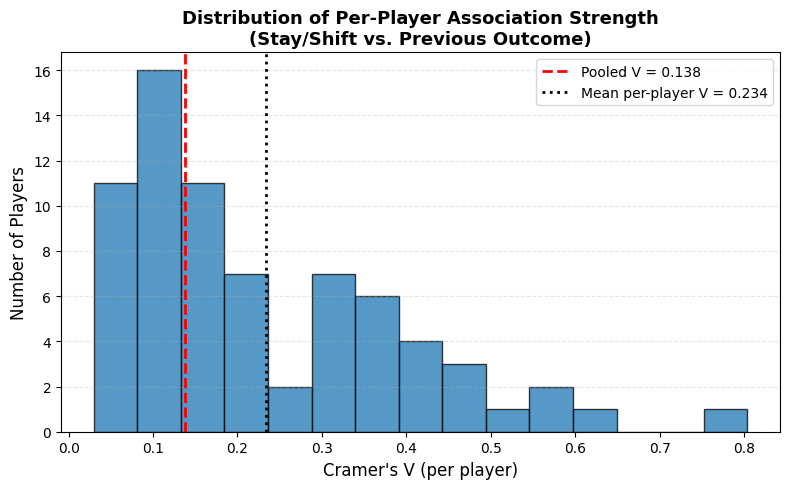


=== Bonferroni-adjusted CI percentiles (for the K=4 bootstrap table) ===
Use percentiles [0.208%, 99.792%] instead of [2.5%, 97.5%]
(i.e., replace np.percentile(bootstrap_array, 2.5/97.5, axis=0) with these values)


In [ ]:
### =========================================================
### תא 1: התקנה מהירה (בלי numpyro/jax/hmmlearn - לא נחוצים כאן)
### =========================================================
!pip install pyreadr -q

import numpy as np
import pandas as pd
import pyreadr
import urllib.request
from scipy.stats import chisquare, chi2_contingency

url = "https://raw.githubusercontent.com/fdvorak/stratEst/master/data/WXZ2014.rda"
urllib.request.urlretrieve(url, "WXZ2014.rda")
result = pyreadr.read_r("WXZ2014.rda")
df = result["WXZ2014"]

df["prev_choice"] = df.groupby("id")["choice"].shift(1)
df["stay"] = (df["choice"] == df["prev_choice"]).astype(int)
df["result_prev"] = df.groupby("id")["result"].shift(1)
df_clean = df.dropna().copy()

print(f"df_clean shape: {df_clean.shape}")

### =========================================================
### תא 2: מבחן טיב-התאמה (GOF) מול Nash Equilibrium
### H0: P(Rock) = P(Paper) = P(Scissors) = 1/3
### =========================================================
choice_counts = df_clean["choice"].value_counts()
print("\n=== Observed choice frequencies ===")
print(choice_counts)

n_total = choice_counts.sum()
observed = choice_counts.values
expected = np.full(len(observed), n_total / len(observed))  # 1/3 כל אחד

chi2_stat, p_value_gof = chisquare(f_obs=observed, f_exp=expected)

print("\n=== Goodness-of-Fit Test vs. Nash Equilibrium (1/3, 1/3, 1/3) ===")
print(f"Chi-square statistic : {chi2_stat:.3f}")
print(f"Degrees of freedom    : {len(observed)-1}")
print(f"p-value               : {p_value_gof:.6f}")
if p_value_gof < 0.05:
    print(">>> Reject H0: choice frequencies deviate significantly from Nash equilibrium.")
else:
    print(">>> Fail to reject H0: choice frequencies are consistent with Nash equilibrium.")

### =========================================================
### תא 3: מבחן אי-תלות (Chi-Square Test of Independence)
### H0: Stay/Shift is independent of the previous round's outcome
### =========================================================
contingency = pd.crosstab(df_clean["stay"], df_clean["result_prev"])
print("\n=== Contingency Table: Stay/Shift x Previous Outcome ===")
print(contingency)

chi2_stat_ind, p_value_ind, dof_ind, expected_ind = chi2_contingency(contingency)

print("\n=== Chi-Square Test of Independence: Stay/Shift vs. Previous Outcome ===")
print(f"Chi-square statistic : {chi2_stat_ind:.3f}")
print(f"Degrees of freedom    : {dof_ind}")
print(f"p-value               : {p_value_ind:.2e}")
if p_value_ind < 0.05:
    print(">>> Reject H0: Stay/Shift behavior is significantly dependent on the previous outcome.")
    print(">>> This motivates a model architecture in which emissions are input-driven (§1.2).")
else:
    print(">>> Fail to reject H0: no significant dependence detected.")

# --- Effect size: Cramer's V ---
# עם n גדול, כמעט כל סטייה תצא "מובהקת" - Cramer's V מודד את
# *עוצמת* הקשר, לא רק אם הוא קיים. טווח: 0 (אין קשר) עד 1 (מושלם).
N = contingency.sum().sum()
r, c = contingency.shape
cramers_v = np.sqrt(chi2_stat_ind / (N * (min(r, c) - 1)))

print(f"\nCramer's V (effect size): {cramers_v:.4f}")
if cramers_v < 0.1:
    strength = "negligible"
elif cramers_v < 0.3:
    strength = "small"
elif cramers_v < 0.5:
    strength = "medium"
else:
    strength = "large"
print(f">>> Effect size interpretation: {strength}")

### =========================================================
### תא 3.1: אותו מבחן, אבל ברמת השחקן - כדי לבדוק אם ההטרוגניות
### בין שחקנים "מדללת" את האפקט המצרפי (pooled)
### =========================================================
per_player_results = []

for pid, group in df_clean.groupby("id"):
    tbl = pd.crosstab(group["stay"], group["result_prev"])
    for col in ["win", "lose", "tie"]:
        if col not in tbl.columns:
            tbl[col] = 0
    tbl = tbl[["win", "lose", "tie"]]

    if tbl.shape[0] < 2 or (tbl.sum(axis=0) == 0).any():
        continue  # שחקן ללא מספיק וריאציה לבדיקה תקינה

    chi2_p, p_p, dof_p, exp_p = chi2_contingency(tbl)
    N_p = tbl.sum().sum()
    V_p = np.sqrt(chi2_p / (N_p * (min(tbl.shape) - 1)))

    per_player_results.append({
        "player_id": pid,
        "n_rounds": N_p,
        "chi2": chi2_p,
        "p_value": p_p,
        "cramers_v": V_p,
    })

df_per_player = pd.DataFrame(per_player_results)

print("\n" + "=" * 65)
print("  PER-PLAYER INDEPENDENCE TEST: DOES POOLING DILUTE THE EFFECT?")
print("=" * 65)
print(f"Players tested: {len(df_per_player)}")
print(f"\nPer-player Cramer's V distribution:")
print(f"  Mean   : {df_per_player['cramers_v'].mean():.3f}")
print(f"  Median : {df_per_player['cramers_v'].median():.3f}")
print(f"  Min    : {df_per_player['cramers_v'].min():.3f}")
print(f"  Max    : {df_per_player['cramers_v'].max():.3f}")
print(f"  25th percentile : {df_per_player['cramers_v'].quantile(0.25):.3f}")
print(f"  75th percentile : {df_per_player['cramers_v'].quantile(0.75):.3f}")

print(f"\nPooled (population-level) Cramer's V : {cramers_v:.3f}")
print(f"Mean per-player Cramer's V            : {df_per_player['cramers_v'].mean():.3f}")

n_significant_raw = (df_per_player["p_value"] < 0.05).sum()
n_significant_bonf = (df_per_player["p_value"] < (0.05 / len(df_per_player))).sum()
print(f"\nPlayers individually significant (raw p<0.05)         : {n_significant_raw} / {len(df_per_player)}")
print(f"Players individually significant (Bonferroni-corrected): {n_significant_bonf} / {len(df_per_player)}")

# --- היסטוגרמה ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_per_player["cramers_v"], bins=15, color="#1f77b4", alpha=0.75, edgecolor="black")
ax.axvline(cramers_v, color="red", linestyle="--", linewidth=2,
           label=f"Pooled V = {cramers_v:.3f}")
ax.axvline(df_per_player["cramers_v"].mean(), color="black", linestyle=":", linewidth=2,
           label=f"Mean per-player V = {df_per_player['cramers_v'].mean():.3f}")
ax.set_xlabel("Cramer's V (per player)", fontsize=12)
ax.set_ylabel("Number of Players", fontsize=12)
ax.set_title("Distribution of Per-Player Association Strength\n"
             "(Stay/Shift vs. Previous Outcome)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("/content/per_player_cramers_v.png", dpi=200, bbox_inches="tight")
plt.show()

### =========================================================
### תא 4: פונקציית עזר - תיקון Bonferroni (שתי דרכים שקולות)
### =========================================================

def bonferroni_correction(p_values, alpha=0.05):
    """
    מקבל רשימת p-values גולמיים, מחזיר:
    - adjusted_alpha: הסף המחולק (alpha / n)
    - adjusted_p: ה-p-values מוכפלים (עם תקרה של 1.0)
    - significant: האם כל אחד מובהק אחרי התיקון
    שתי הדרכים (השוואה ל-adjusted_alpha, או p מוכפל מול alpha
    הרגיל) שקולות מתמטית ונותנות אותה תוצאה.
    """
    p_values = np.array(p_values)
    n = len(p_values)
    adjusted_alpha = alpha / n
    adjusted_p = np.minimum(p_values * n, 1.0)
    significant = p_values < adjusted_alpha  # == adjusted_p < alpha
    return adjusted_alpha, adjusted_p, significant


def bonferroni_ci_percentiles(alpha=0.05, n_comparisons=12):
    """
    עבור bootstrap CI (לא p-values): מחזיר את האחוזונים המתוקנים
    (במקום 2.5%/97.5% הרגילים) שמשמרים family-wise error rate.
    """
    adj_alpha = alpha / n_comparisons
    lower_pct = 100 * (adj_alpha / 2)
    upper_pct = 100 * (1 - adj_alpha / 2)
    return lower_pct, upper_pct


# --- דוגמת שימוש (לטבלת ה-bootstrap, 4 מצבים x 3 תוצאות = 12 השוואות) ---
lower_pct, upper_pct = bonferroni_ci_percentiles(alpha=0.05, n_comparisons=12)
print(f"\n=== Bonferroni-adjusted CI percentiles (for the K=4 bootstrap table) ===")
print(f"Use percentiles [{lower_pct:.3f}%, {upper_pct:.3f}%] instead of [2.5%, 97.5%]")
print("(i.e., replace np.percentile(bootstrap_array, 2.5/97.5, axis=0) with these values)")

In [ ]:
import numpy as np
from scipy.stats import norm

# =========================================================
# נתוני ה-bootstrap שכבר יש לך (K=4) - Mean ו-Std Error בלבד,
# לא צריך את מערך ה-bootstrap הגולמי בכלל
# =========================================================
bootstrap_results = {
    ("Loss-Shift (WSLS)", "Win"):  {"mean": 1.1632, "se": 0.3946},
    ("Loss-Shift (WSLS)", "Lose"): {"mean": -2.3121, "se": 0.7431},
    ("Loss-Shift (WSLS)", "Tie"):  {"mean": 0.4147, "se": 0.6887},
    ("Random / Indecisive", "Win"):  {"mean": 0.1449, "se": 0.4703},
    ("Random / Indecisive", "Lose"): {"mean": -0.0900, "se": 0.7455},
    ("Random / Indecisive", "Tie"):  {"mean": 0.0947, "se": 0.4523},
    ("Freezing", "Win"):  {"mean": 1.0550, "se": 0.3004},
    ("Freezing", "Lose"): {"mean": 1.1131, "se": 0.1614},
    ("Freezing", "Tie"):  {"mean": 0.9365, "se": 0.2605},
    ("Chronic-Shift", "Win"):  {"mean": -0.8319, "se": 0.5858},
    ("Chronic-Shift", "Lose"): {"mean": -2.9966, "se": 0.6826},
    ("Chronic-Shift", "Tie"):  {"mean": -1.7330, "se": 0.3975},
}

n_comparisons = len(bootstrap_results)  # 12
alpha = 0.05
alpha_adjusted = alpha / n_comparisons
z_adjusted = norm.ppf(1 - alpha_adjusted / 2)

z_original = norm.ppf(1 - alpha / 2)  # 1.96, לצורך השוואה

print(f"Number of comparisons: {n_comparisons}")
print(f"Original 95% CI z-score       : {z_original:.4f}")
print(f"Bonferroni-adjusted z-score   : {z_adjusted:.4f}")
print(f"(equivalent adjusted confidence level: {100*(1-alpha_adjusted):.2f}%)\n")

print(f"{'State':<22} {'Feature':<8} {'Mean':<9} {'95% CI (raw)':<22} {'95% CI (Bonferroni)':<22}")
print("-" * 90)

for (state, feature), vals in bootstrap_results.items():
    mean, se = vals["mean"], vals["se"]

    ci_raw_lo, ci_raw_hi = mean - z_original * se, mean + z_original * se
    ci_adj_lo, ci_adj_hi = mean - z_adjusted * se, mean + z_adjusted * se

    print(f"{state:<22} {feature:<8} {mean:<9.3f} "
          f"({ci_raw_lo:6.3f}, {ci_raw_hi:6.3f})   "
          f"({ci_adj_lo:6.3f}, {ci_adj_hi:6.3f})")

print("""
Note: these are normal-approximation (Wald-type) intervals, using the
bootstrap standard error already computed. This differs slightly from
reading adjusted percentiles directly off the bootstrap distribution,
but is a standard and defensible approximation when the SE is already
known and the sampling distribution is reasonably symmetric (as is the
case here, since estimates are on the unbounded logit scale).
""")

Number of comparisons: 12
Original 95% CI z-score       : 1.9600
Bonferroni-adjusted z-score   : 2.8653
(equivalent adjusted confidence level: 99.58%)

State                  Feature  Mean      95% CI (raw)           95% CI (Bonferroni)   
------------------------------------------------------------------------------------------
Loss-Shift (WSLS)      Win      1.163     ( 0.390,  1.937)   ( 0.033,  2.294)
Loss-Shift (WSLS)      Lose     -2.312    (-3.769, -0.856)   (-4.441, -0.183)
Loss-Shift (WSLS)      Tie      0.415     (-0.935,  1.765)   (-1.559,  2.388)
Random / Indecisive    Win      0.145     (-0.777,  1.067)   (-1.203,  1.492)
Random / Indecisive    Lose     -0.090    (-1.551,  1.371)   (-2.226,  2.046)
Random / Indecisive    Tie      0.095     (-0.792,  0.981)   (-1.201,  1.391)
Freezing               Win      1.055     ( 0.466,  1.644)   ( 0.194,  1.916)
Freezing               Lose     1.113     ( 0.797,  1.429)   ( 0.651,  1.576)
Freezing               Tie      0.936     ( 0

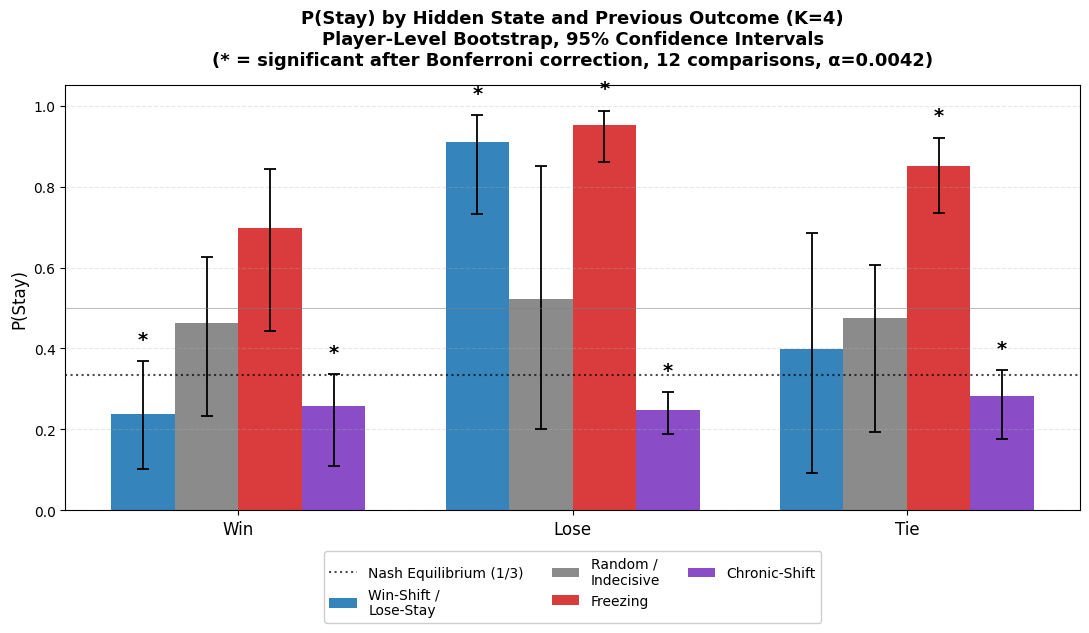

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# נתונים מוזנים ידנית מתוצאות ה-Bootstrap (K=4)
# כדי שהגרף יעבוד גם בלי משתנים שרדו ב-session (למקרה ניתוק)
# =========================================================

states = ["Win-Shift /\nLose-Stay", "Random /\nIndecisive", "Freezing", "Chronic-Shift"]
features = ["Win", "Lose", "Tie"]

# P(Stay) Mean, 95% CI Lower, 95% CI Upper -- corrected values (sigmoid(-W)),
# with Freezing/Chronic-Shift correctly relabeled
p_stay = {
    "Win-Shift /\nLose-Stay": {"mean": [0.238, 0.910, 0.398], "lo": [0.103, 0.732, 0.093], "hi": [0.369, 0.976, 0.685]},
    "Random /\nIndecisive":   {"mean": [0.464, 0.522, 0.476], "lo": [0.234, 0.200, 0.193], "hi": [0.625, 0.852, 0.605]},
    "Freezing":               {"mean": [0.697, 0.952, 0.850], "lo": [0.444, 0.861, 0.736], "hi": [0.843, 0.988, 0.921]},
    "Chronic-Shift":          {"mean": [0.258, 0.247, 0.282], "lo": [0.109, 0.188, 0.176], "hi": [0.337, 0.292, 0.346]},
}

STATE_COLORS = ["#1f77b4", "#7f7f7f", "#d62728", "#7d3ac1"]  # Loss-Shift, Random, Freezing, Chronic-Shift

# תאים ש**שורדים** תיקון Bonferroni (12 השוואות, alpha=0.05/12≈0.0042)
# מבוסס על p-values שחושבו מ-mean/SE של ה-bootstrap
SIGNIFICANT_AFTER_CORRECTION = {
    ("Win-Shift /\nLose-Stay", "Win"),
    ("Win-Shift /\nLose-Stay", "Lose"),
    ("Chronic-Shift", "Win"),
    ("Chronic-Shift", "Lose"),
    ("Chronic-Shift", "Tie"),
    ("Freezing", "Lose"),
    ("Freezing", "Tie"),
}

# =========================================================
# בניית הגרף - Grouped Bar Chart, מקובץ לפי Feature (Win/Lose/Tie)
# =========================================================
fig, ax = plt.subplots(figsize=(11, 6.5))

n_states = len(states)
n_features = len(features)
bar_width = 0.19
x = np.arange(n_features)  # מיקום בסיס לכל feature (Win, Lose, Tie)

for i, state in enumerate(states):
    means = p_stay[state]["mean"]
    los = p_stay[state]["lo"]
    his = p_stay[state]["hi"]
    err_lower = [m - l for m, l in zip(means, los)]
    err_upper = [h - m for m, h in zip(means, his)]

    offset = (i - (n_states - 1) / 2) * bar_width
    bar_positions = x + offset
    ax.bar(
        bar_positions, means, bar_width,
        yerr=[err_lower, err_upper], capsize=4,
        color=STATE_COLORS[i], alpha=0.9, label=state,
        error_kw={"elinewidth": 1.3, "capthick": 1.3}
    )

    # כוכבית מעל עמודות שמובהקות גם אחרי תיקון Bonferroni
    for j, feat in enumerate(features):
        if (state, feat) in SIGNIFICANT_AFTER_CORRECTION:
            star_y = his[j] + 0.03
            ax.text(bar_positions[j], star_y, "*", ha="center", va="bottom",
                    fontsize=14, fontweight="bold", color="black")

# קו ייחוס: שיווי משקל נאש (1/3)
ax.axhline(y=1/3, color="black", linestyle=":", linewidth=1.5, alpha=0.7,
           label="Nash Equilibrium (1/3)")

# קו ייחוס: הטלת מטבע / אדישות (0.5)
ax.axhline(y=0.5, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(features, fontsize=12)
ax.set_ylabel("P(Stay)", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("P(Stay) by Hidden State and Previous Outcome (K=4)\n"
             "Player-Level Bootstrap, 95% Confidence Intervals\n"
             "(* = significant after Bonferroni correction, 12 comparisons, α=0.0042)",
             fontsize=13, fontweight="bold", pad=15)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, framealpha=0.95, fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()